# Unsupervised Learning: Trade & Ahead

## Problem Statement

### Context

The stock market has consistently proven to be a good place to invest in and save for the future. There are a lot of compelling reasons to invest in stocks. It can help in fighting inflation, create wealth, and also provides some tax benefits. Good steady returns on investments over a long period of time can also grow a lot more than seems possible. Also, thanks to the power of compound interest, the earlier one starts investing, the larger the corpus one can have for retirement. Overall, investing in stocks can help meet life's financial aspirations.

It is important to maintain a diversified portfolio when investing in stocks in order to maximise earnings under any market condition. Having a diversified portfolio tends to yield higher returns and face lower risk by tempering potential losses when the market is down. It is often easy to get lost in a sea of financial metrics to analyze while determining the worth of a stock, and doing the same for a multitude of stocks to identify the right picks for an individual can be a tedious task. By doing a cluster analysis, one can identify stocks that exhibit similar characteristics and ones which exhibit minimum correlation. This will help investors better analyze stocks across different market segments and help protect against risks that could make the portfolio vulnerable to losses.


### Objective

Trade&Ahead is a financial consultancy firm who provide their customers with personalized investment strategies. They have hired you as a Data Scientist and provided you with data comprising stock price and some financial indicators for a few companies listed under the New York Stock Exchange. They have assigned you the tasks of analyzing the data, grouping the stocks based on the attributes provided, and sharing insights about the characteristics of each group.

### Data Dictionary

- Ticker Symbol: An abbreviation used to uniquely identify publicly traded shares of a particular stock on a particular stock market
- Company: Name of the company
- GICS Sector: The specific economic sector assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- GICS Sub Industry: The specific sub-industry group assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- Current Price: Current stock price in dollars
- Price Change: Percentage change in the stock price in 13 weeks
- Volatility: Standard deviation of the stock price over the past 13 weeks
- ROE: A measure of financial performance calculated by dividing net income by shareholders' equity (shareholders' equity is equal to a company's assets minus its debt)
- Cash Ratio: The ratio of a  company's total reserves of cash and cash equivalents to its total current liabilities
- Net Cash Flow: The difference between a company's cash inflows and outflows (in dollars)
- Net Income: Revenues minus expenses, interest, and taxes (in dollars)
- Earnings Per Share: Company's net profit divided by the number of common shares it has outstanding (in dollars)
- Estimated Shares Outstanding: Company's stock currently held by all its shareholders
- P/E Ratio: Ratio of the company's current stock price to the earnings per share
- P/B Ratio: Ratio of the company's stock price per share by its book value per share (book value of a company is the net difference between that company's total assets and total liabilities)

## Importing necessary libraries and data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist, pdist
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

## Data Overview

- Observations
- Sanity checks

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data= pd.read_csv('/content/drive/MyDrive/Colab Notebooks/stock_data.csv')
data.head()

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
0,AAL,American Airlines Group,Industrials,Airlines,42.349998,9.999995,1.687151,135,51,-604000000,7610000000,11.39,6.681299e+08,3.718174,-8.784219
1,ABBV,AbbVie,Health Care,Pharmaceuticals,59.240002,8.339433,2.197887,130,77,51000000,5144000000,3.15,1.633016e+09,18.806350,-8.750068
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,44.910000,11.301121,1.273646,21,67,938000000,4423000000,2.94,1.504422e+09,15.275510,-0.394171
3,ADBE,Adobe Systems Inc,Information Technology,Application Software,93.940002,13.977195,1.357679,9,180,-240840000,629551000,1.26,4.996437e+08,74.555557,4.199651
4,ADI,"Analog Devices, Inc.",Information Technology,Semiconductors,55.320000,-1.827858,1.701169,14,272,315120000,696878000,0.31,2.247994e+09,178.451613,1.059810


In [4]:
data.shape

(340, 15)

In [5]:
df= data.copy()

In [6]:
df.sample(n=10, random_state=1)

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
102,DVN,Devon Energy Corp.,Energy,Oil & Gas Exploration & Production,32.000000,-15.478079,2.923698,205,70,830000000,-14454000000,-35.55,4.065823e+08,93.089287,1.785616
125,FB,Facebook,Information Technology,Internet Software & Services,104.660004,16.224320,1.320606,8,958,592000000,3669000000,1.31,2.800763e+09,79.893133,5.884467
11,AIV,Apartment Investment & Mgmt,Real Estate,REITs,40.029999,7.578608,1.163334,15,47,21818000,248710000,1.52,1.636250e+08,26.335526,-1.269332
248,PG,Procter & Gamble,Consumer Staples,Personal Products,79.410004,10.660538,0.806056,17,129,160383000,636056000,3.28,4.913916e+08,24.070121,-2.256747
238,OXY,Occidental Petroleum,Energy,Oil & Gas Exploration & Production,67.610001,0.865287,1.589520,32,64,-588000000,-7829000000,-10.23,7.652981e+08,93.089287,3.345102
336,YUM,Yum! Brands Inc,Consumer Discretionary,Restaurants,52.516175,-8.698917,1.478877,142,27,159000000,1293000000,2.97,4.353535e+08,17.682214,-3.838260
112,EQT,EQT Corporation,Energy,Oil & Gas Exploration & Production,52.130001,-21.253771,2.364883,2,201,523803000,85171000,0.56,1.520911e+08,93.089287,9.567952
147,HAL,Halliburton Co.,Energy,Oil & Gas Equipment & Services,34.040001,-5.101751,1.966062,4,189,7786000000,-671000000,-0.79,8.493671e+08,93.089287,17.345857
89,DFS,Discover Financial Services,Financials,Consumer Finance,53.619999,3.653584,1.159897,20,99,2288000000,2297000000,5.14,4.468872e+08,10.431906,-0.375934
173,IVZ,Invesco Ltd.,Financials,Asset Management & Custody Banks,33.480000,7.067477,1.580839,12,67,412000000,968100000,2.26,4.283628e+08,14.814159,4.218620


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticker Symbol                 340 non-null    object 
 1   Security                      340 non-null    object 
 2   GICS Sector                   340 non-null    object 
 3   GICS Sub Industry             340 non-null    object 
 4   Current Price                 340 non-null    float64
 5   Price Change                  340 non-null    float64
 6   Volatility                    340 non-null    float64
 7   ROE                           340 non-null    int64  
 8   Cash Ratio                    340 non-null    int64  
 9   Net Cash Flow                 340 non-null    int64  
 10  Net Income                    340 non-null    int64  
 11  Earnings Per Share            340 non-null    float64
 12  Estimated Shares Outstanding  340 non-null    float64
 13  P/E R

In [8]:
df.describe()

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
count,340.000000,340.000000,340.000000,340.000000,340.000000,3.400000e+02,3.400000e+02,340.000000,3.400000e+02,340.000000,340.000000
mean,80.862345,4.078194,1.525976,39.597059,70.023529,5.553762e+07,1.494385e+09,2.776662,5.770283e+08,32.612563,-1.718249
std,98.055086,12.006338,0.591798,96.547538,90.421331,1.946365e+09,3.940150e+09,6.587779,8.458496e+08,44.348731,13.966912
min,4.500000,-47.129693,0.733163,1.000000,0.000000,-1.120800e+10,-2.352800e+10,-61.200000,2.767216e+07,2.935451,-76.119077
25%,38.555000,-0.939484,1.134878,9.750000,18.000000,-1.939065e+08,3.523012e+08,1.557500,1.588482e+08,15.044653,-4.352056
50%,59.705000,4.819505,1.385593,15.000000,47.000000,2.098000e+06,7.073360e+08,2.895000,3.096751e+08,20.819876,-1.067170
75%,92.880001,10.695493,1.695549,27.000000,99.000000,1.698108e+08,1.899000e+09,4.620000,5.731175e+08,31.764755,3.917066
max,1274.949951,55.051683,4.580042,917.000000,958.000000,2.076400e+10,2.444200e+10,50.090000,6.159292e+09,528.039074,129.064585


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

,0
Ticker Symbol,0
Security,0
GICS Sector,0
GICS Sub Industry,0
Current Price,0
Price Change,0
Volatility,0
ROE,0
Cash Ratio,0
Net Cash Flow,0


## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What does the distribution of stock prices look like?
2. The stocks of which economic sector have seen the maximum price increase on average?
3. How are the different variables correlated with each other?
4. Cash ratio provides a measure of a company's ability to cover its short-term obligations using only cash and cash equivalents. How does the average cash ratio vary across economic sectors?
5. P/E ratios can help determine the relative value of a company's shares as they signify the amount of money an investor is willing to invest in a single share of a company per dollar of its earnings. How does the P/E ratio vary, on average, across economic sectors?

Univariate Analysis

In [11]:
# Defining functions for visualization
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):

    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [12]:
def labeled_barplot(data, feature, perc=False, n=None):

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot


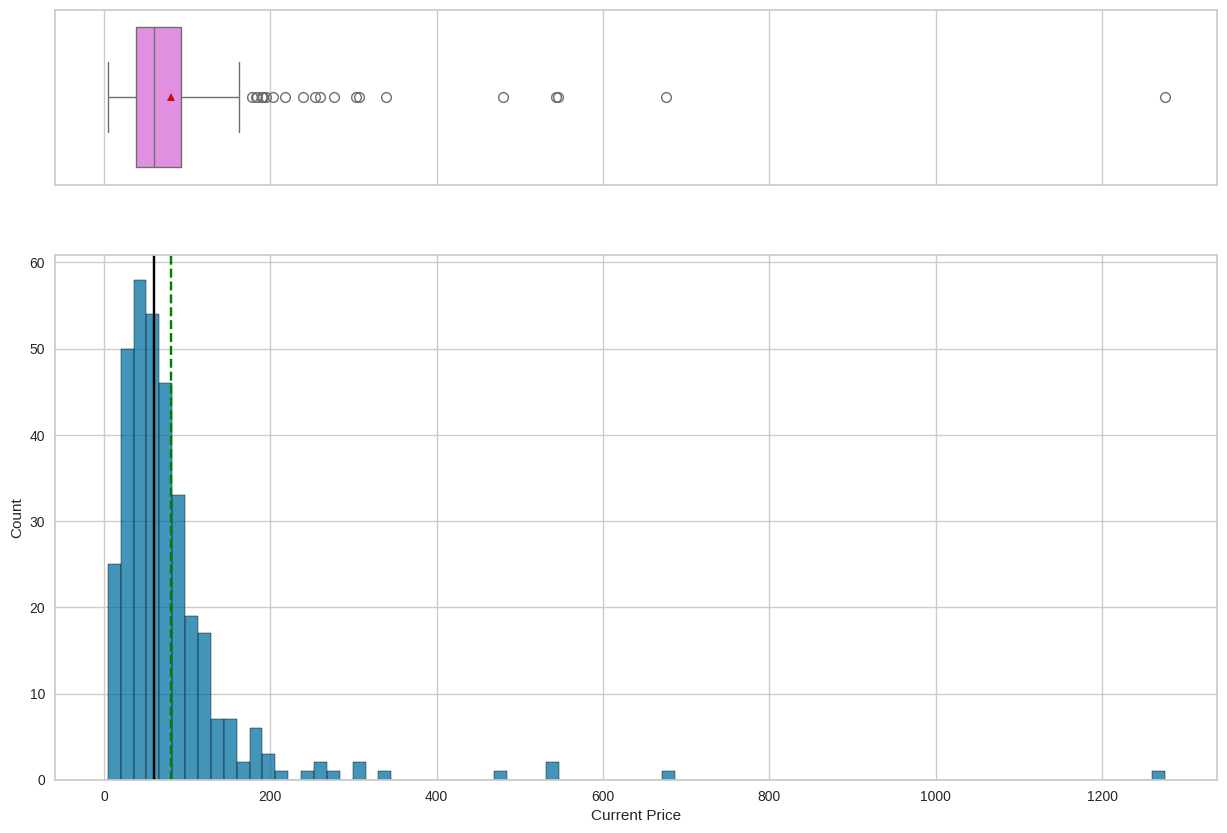

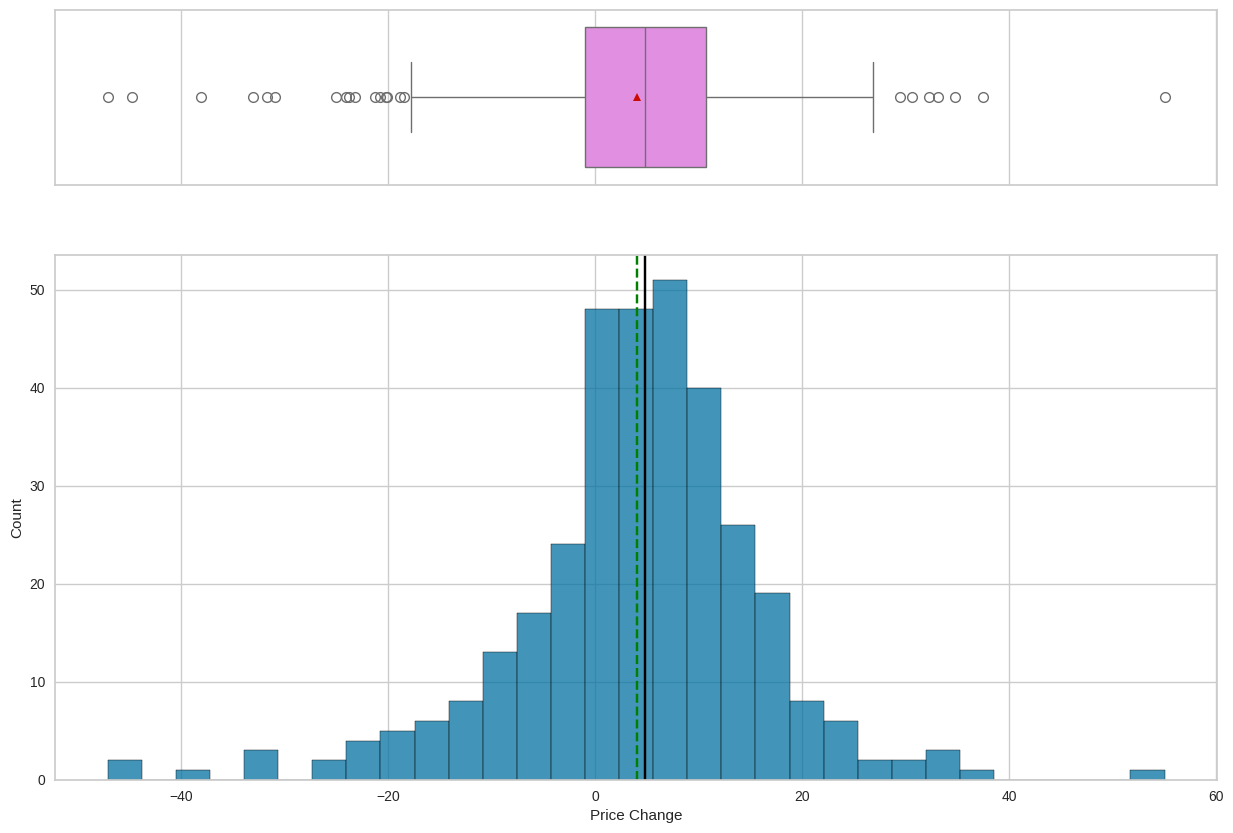

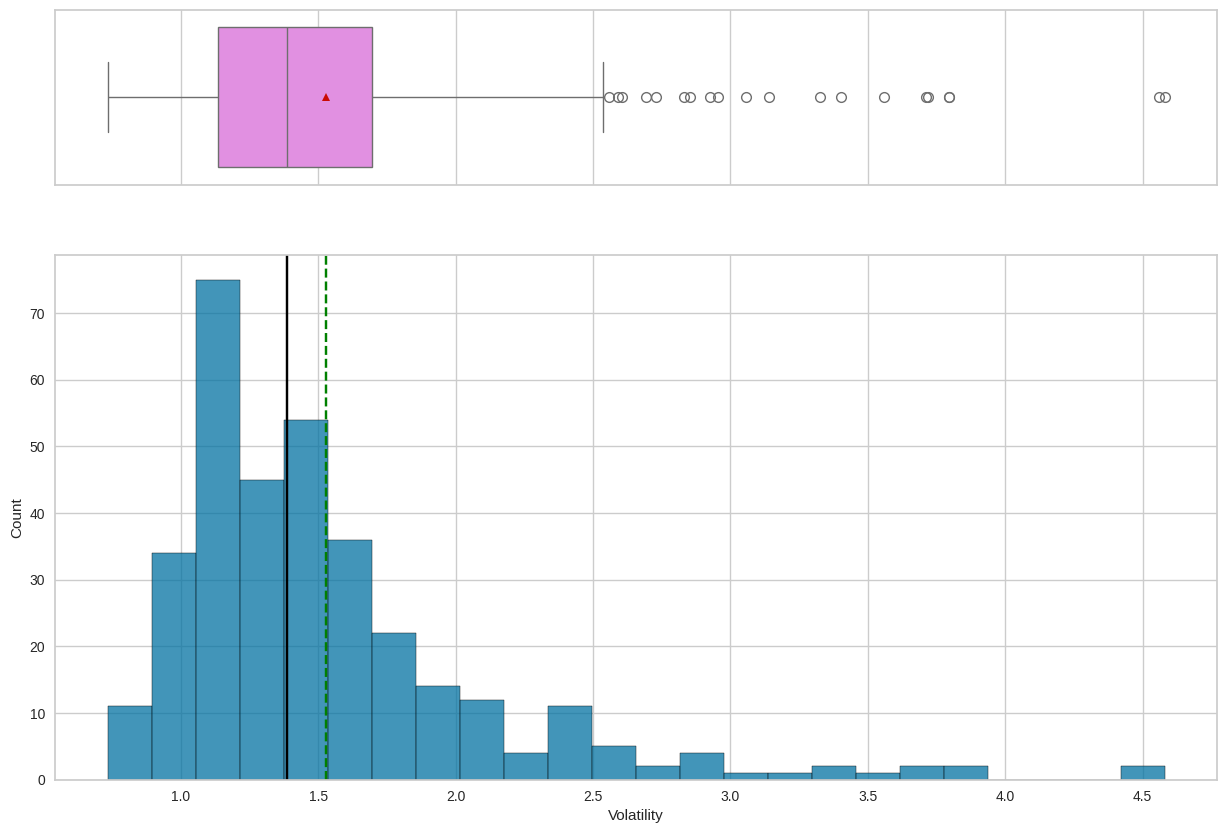

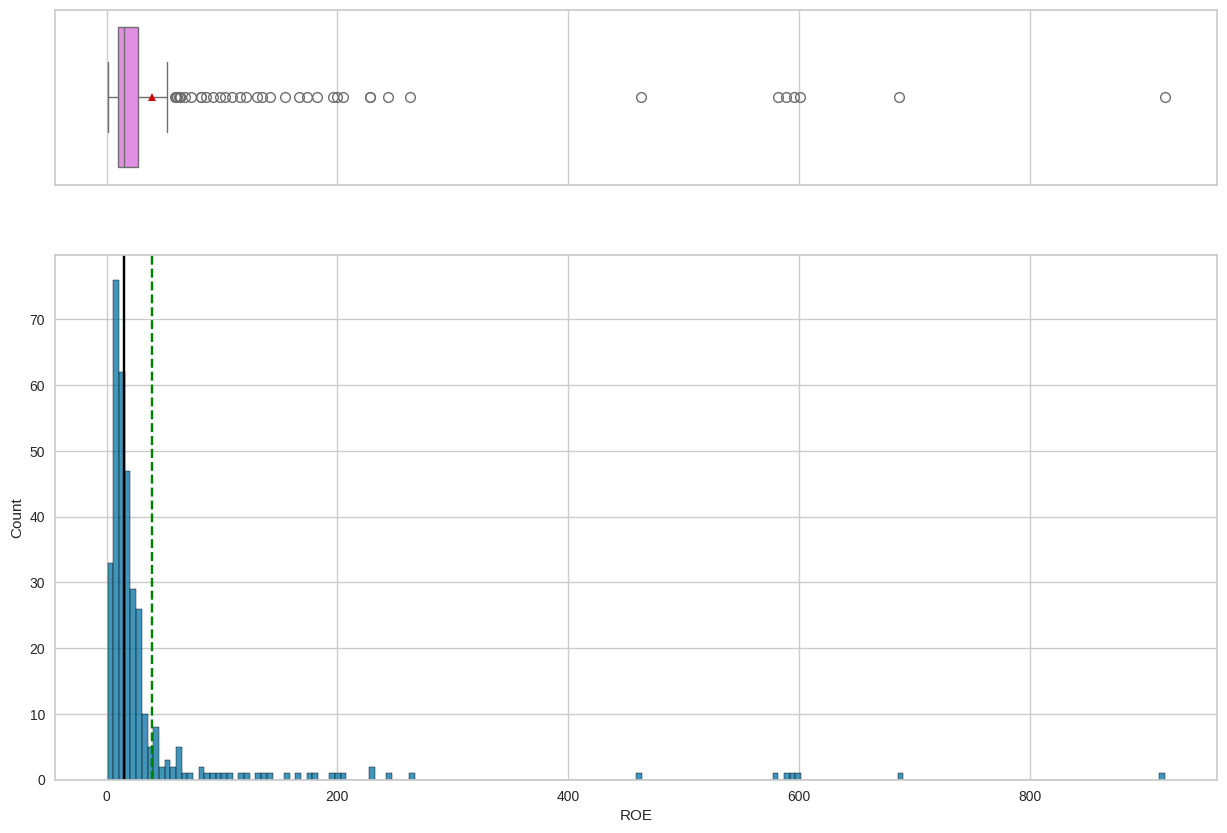

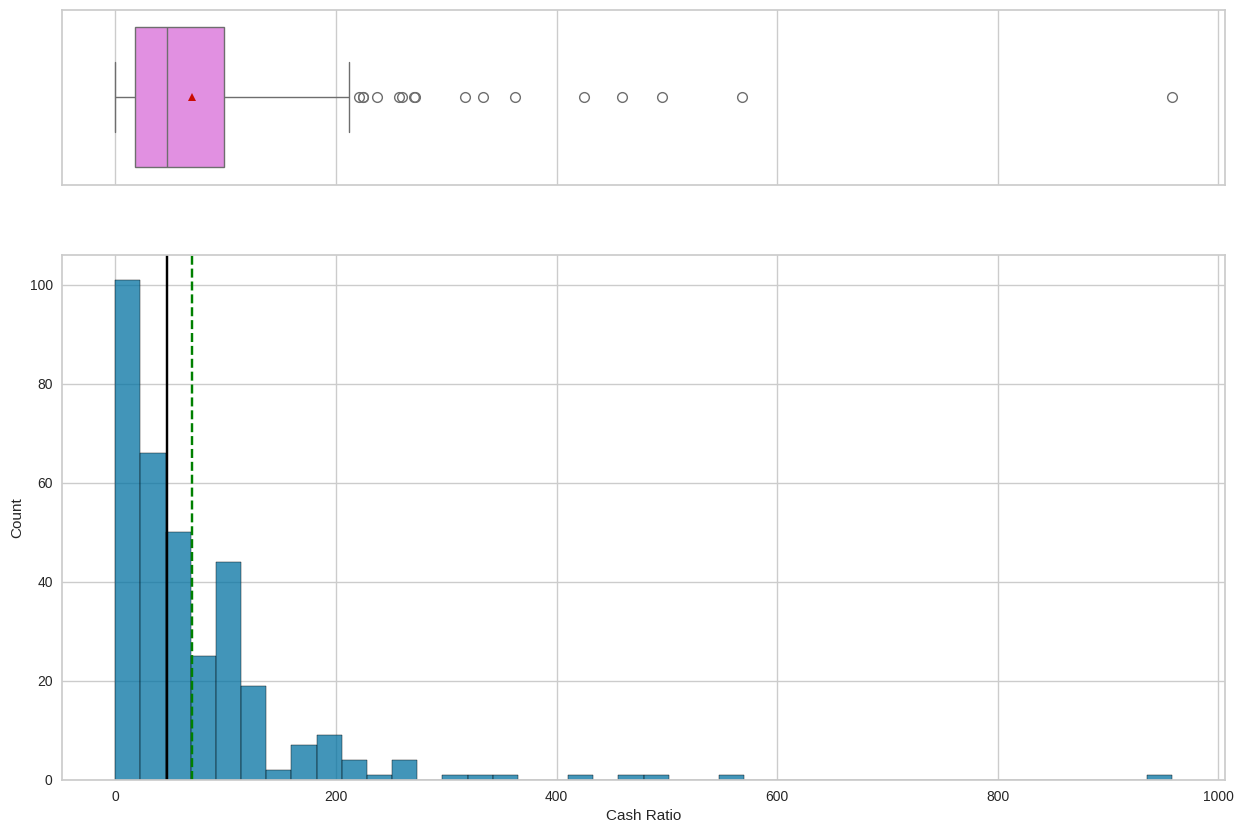

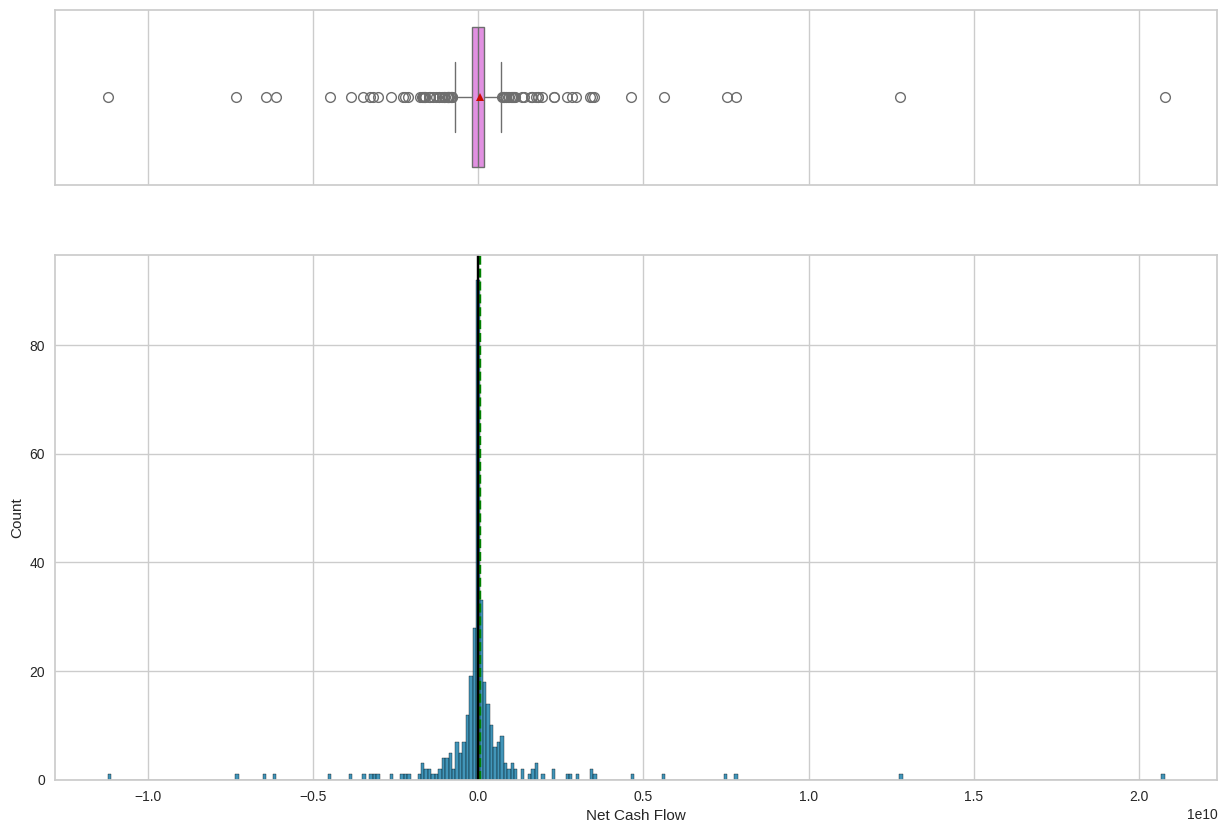

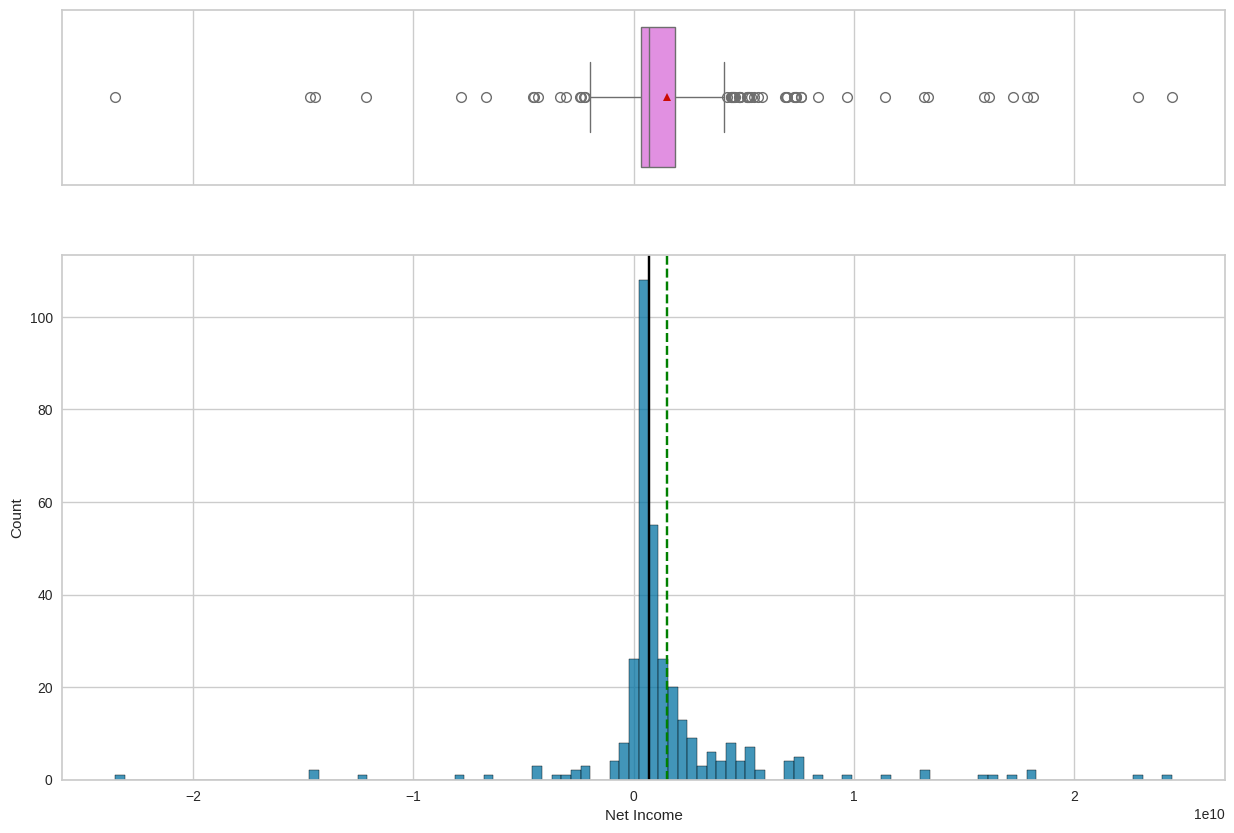

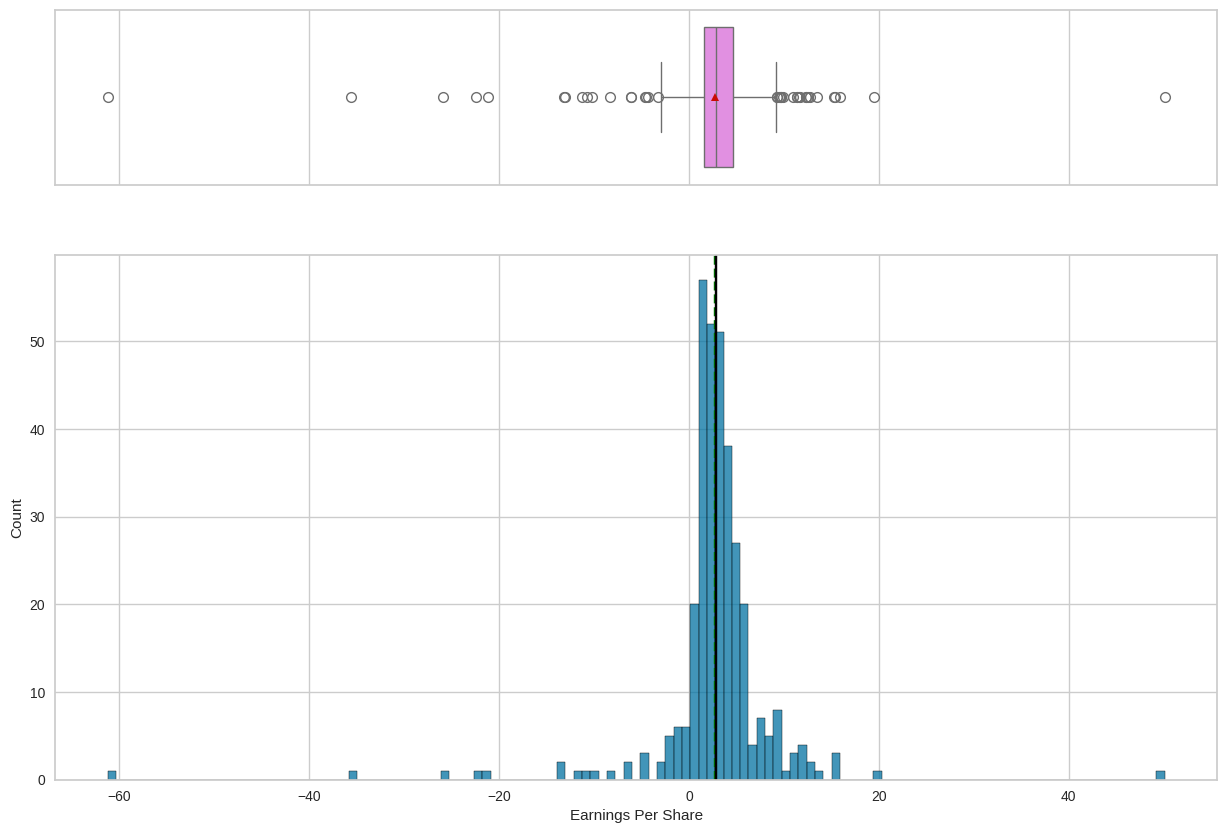

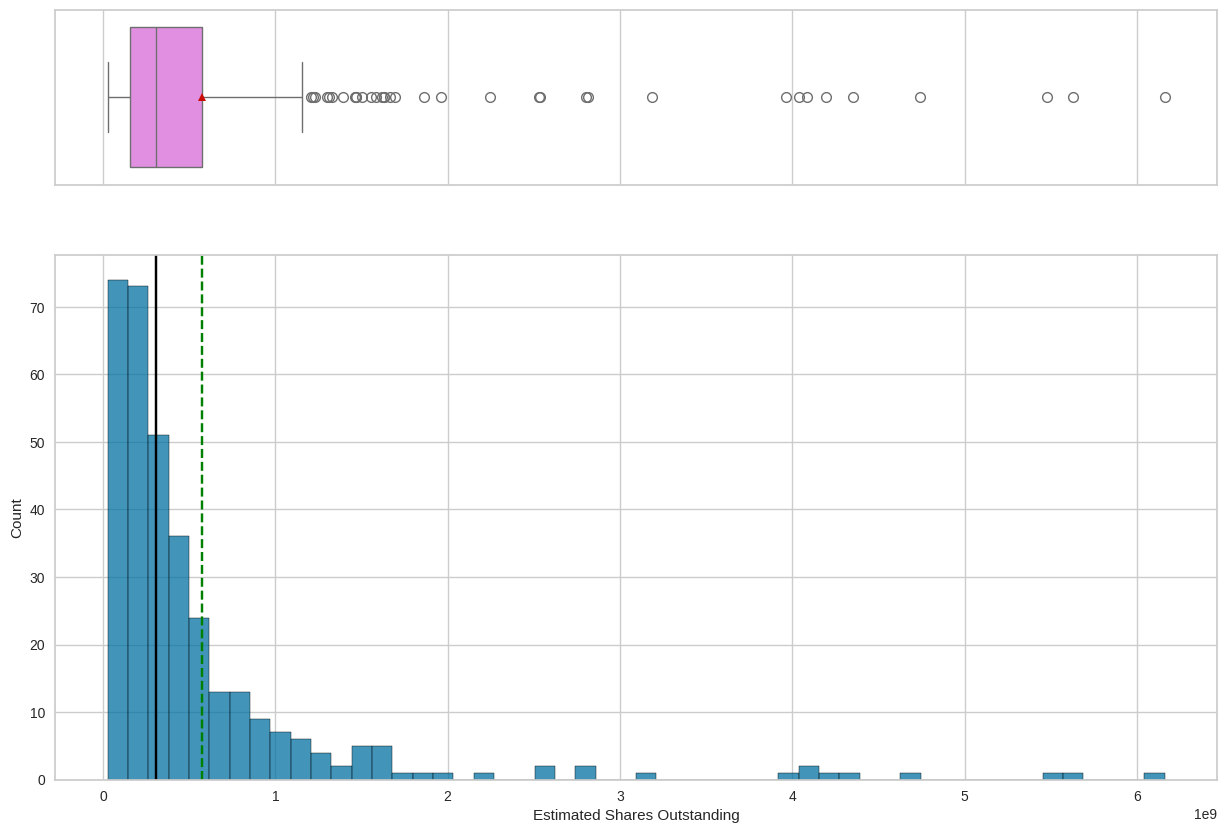

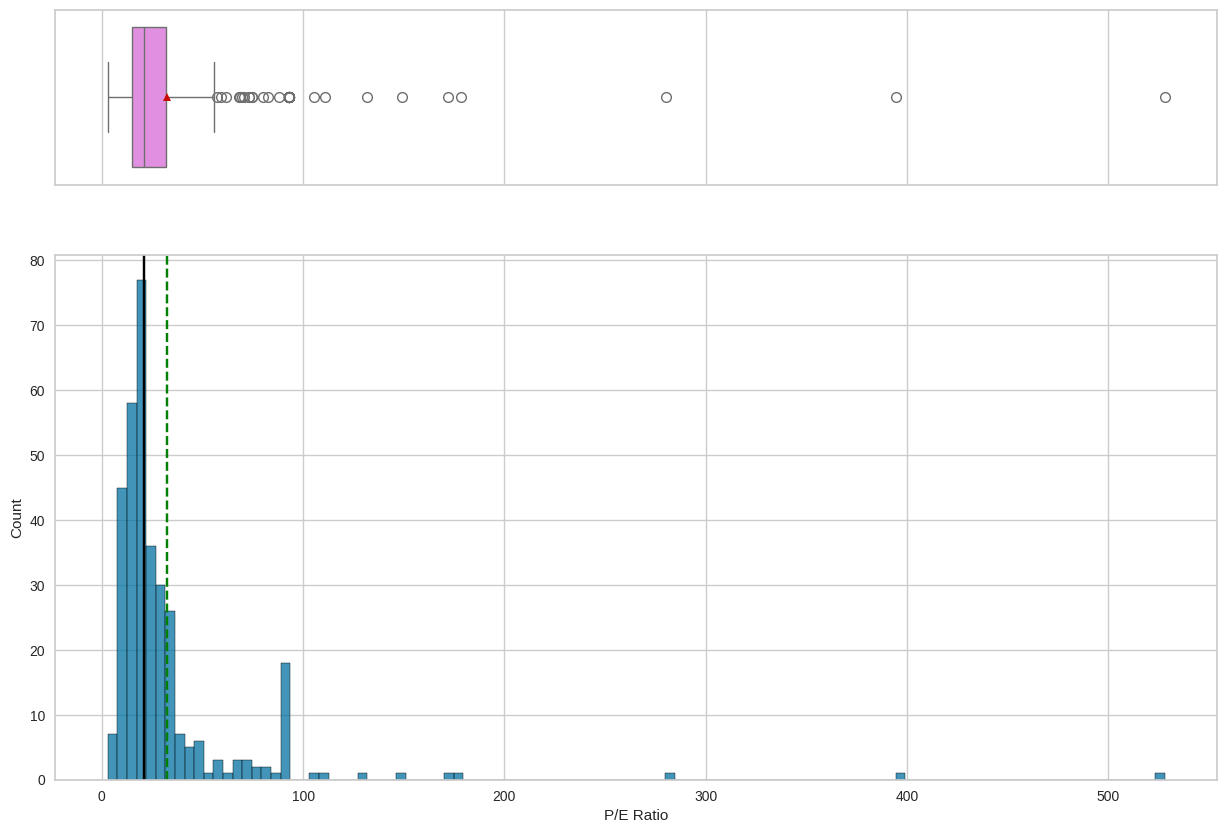

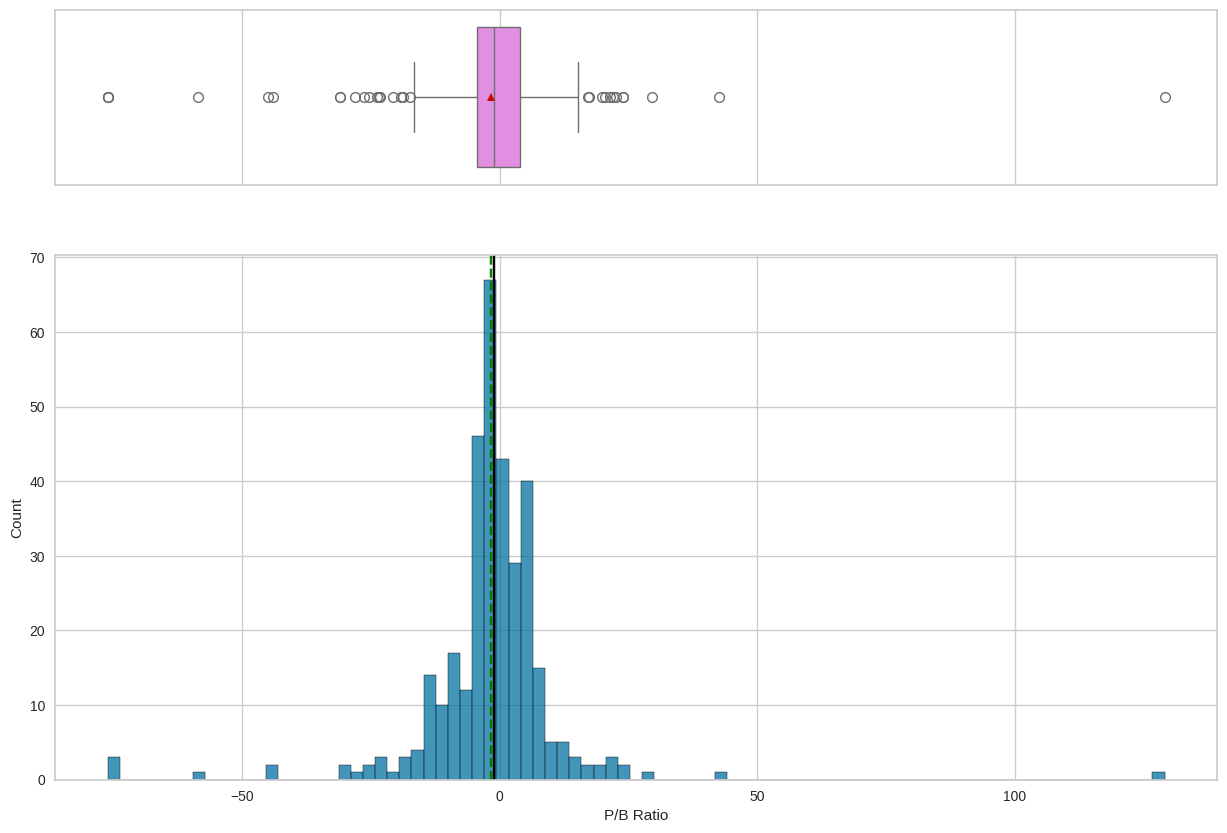

In [13]:
#Visualizing all numerical columns using histogram_boxplot function
num_col = df.select_dtypes(include=np.number).columns.tolist()

for item in num_col:
    histogram_boxplot(df, item)

* Current Price is right skewed, avg price around 80, has some large outliers
* Price change is normally distributed at an avg percentage change 4% with outliers in both directions
* Volatility is rightly skewed, avg std 1.4, outliers reaching 4.5 std
* ROE is rightly skewed, major outliers reaching above 800%, avg ROE being 40%, no companies have a negative ROE
* Cash ratio is heavily right-skewed with a mean of 70 and a median of 47, indicating many companies have low cash ratios but some have extremely high ones up to 958.
* Net Cash Flow has a very wide range, with both large negative and positive outliers, and a mean (5.55e+07) much higher than its median (2.09e+06), suggesting a right-skew due to very large positive flows.
* Net Income is also right-skewed, with a mean (1.49e+09) greater than its median (7.07e+08), and significant outliers on both the negative and positive ends.
* Earnings Per Share shows a wide distribution with both negative and positive values, a mean (2.77) close to the median (2.89), but with considerable outliers, particularly negative ones.
* Estimated Shares Outstanding is highly right-skewed, with a mean (5.77e+08) much larger than its median (3.09e+08), indicating a few companies with a very high number of outstanding shares.
* P/E Ratio is heavily right-skewed, with a mean (32.61) significantly higher than its median (20.81), suggesting many companies have lower P/E ratios, but a substantial number of outliers inflate the mean.
* P/B Ratio has a wide range with both negative and positive values, and significant outliers on both ends. The mean (-1.71) is slightly less than the median (-1.06), but the presence of extreme positive values indicates a complex distribution.

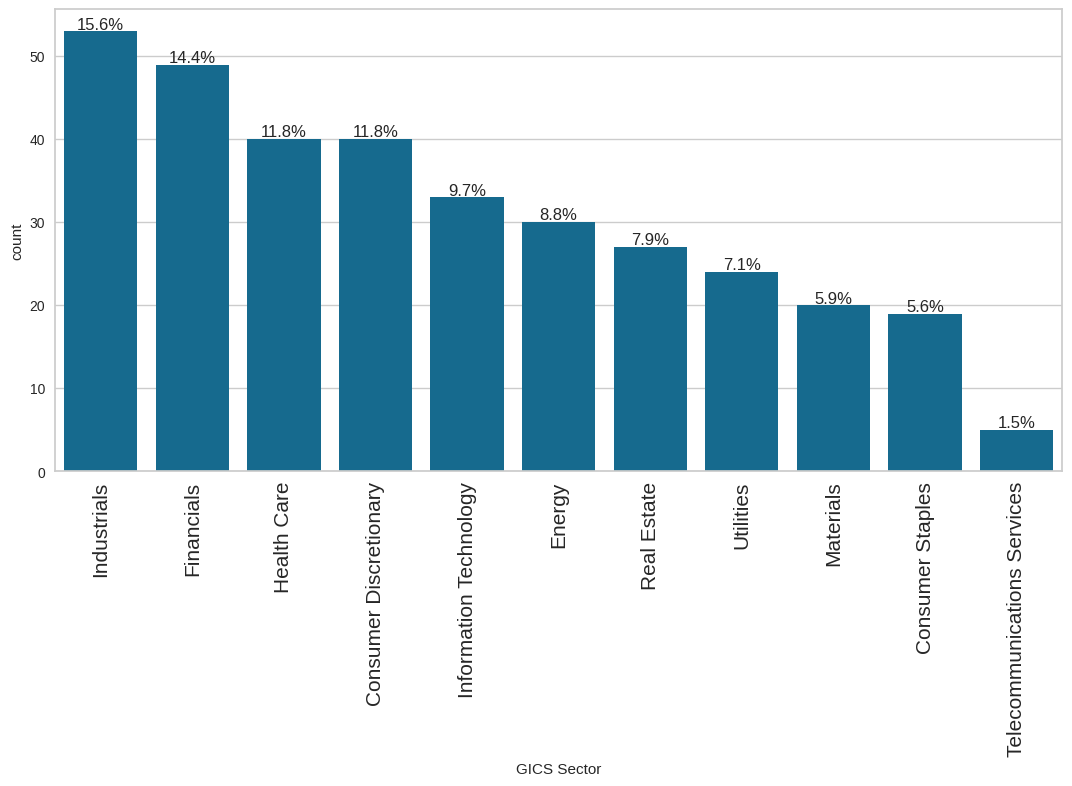

In [14]:
labeled_barplot(df, 'GICS Sector', perc=True)

* Industrials and Financials are the most common sectors in the data

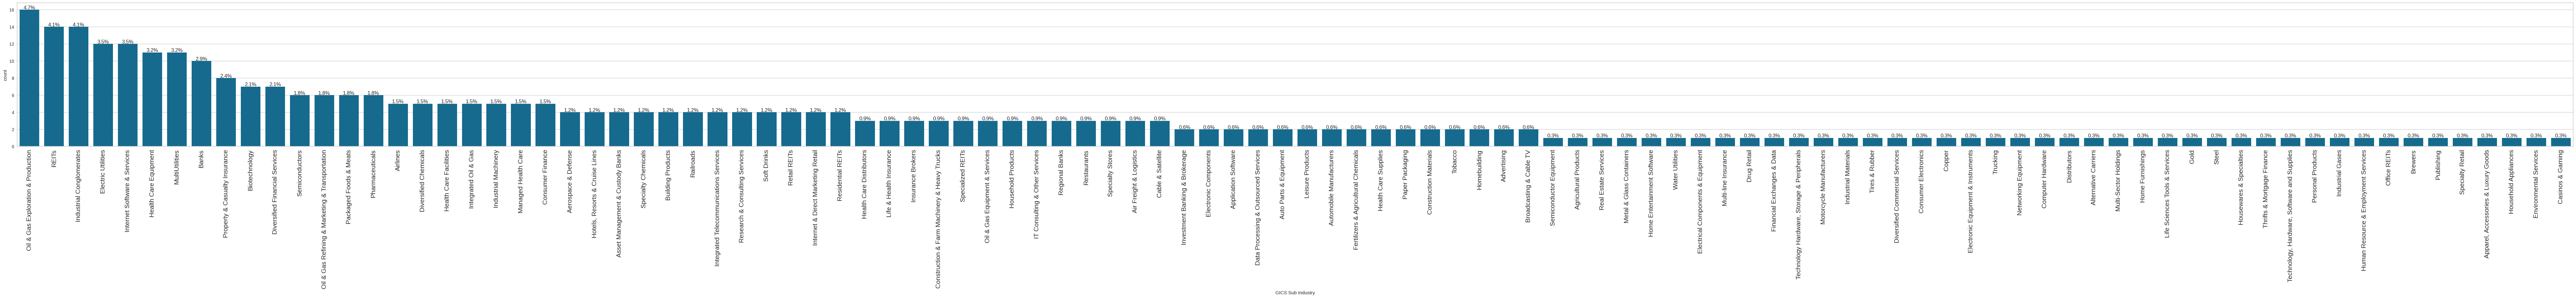

In [15]:
labeled_barplot(df, 'GICS Sub Industry', perc=True)

* Oil and Gas Exploration and Production is the most common sub industry with REITS and Industrial Conglomerates following behind

Bivariate Analysis

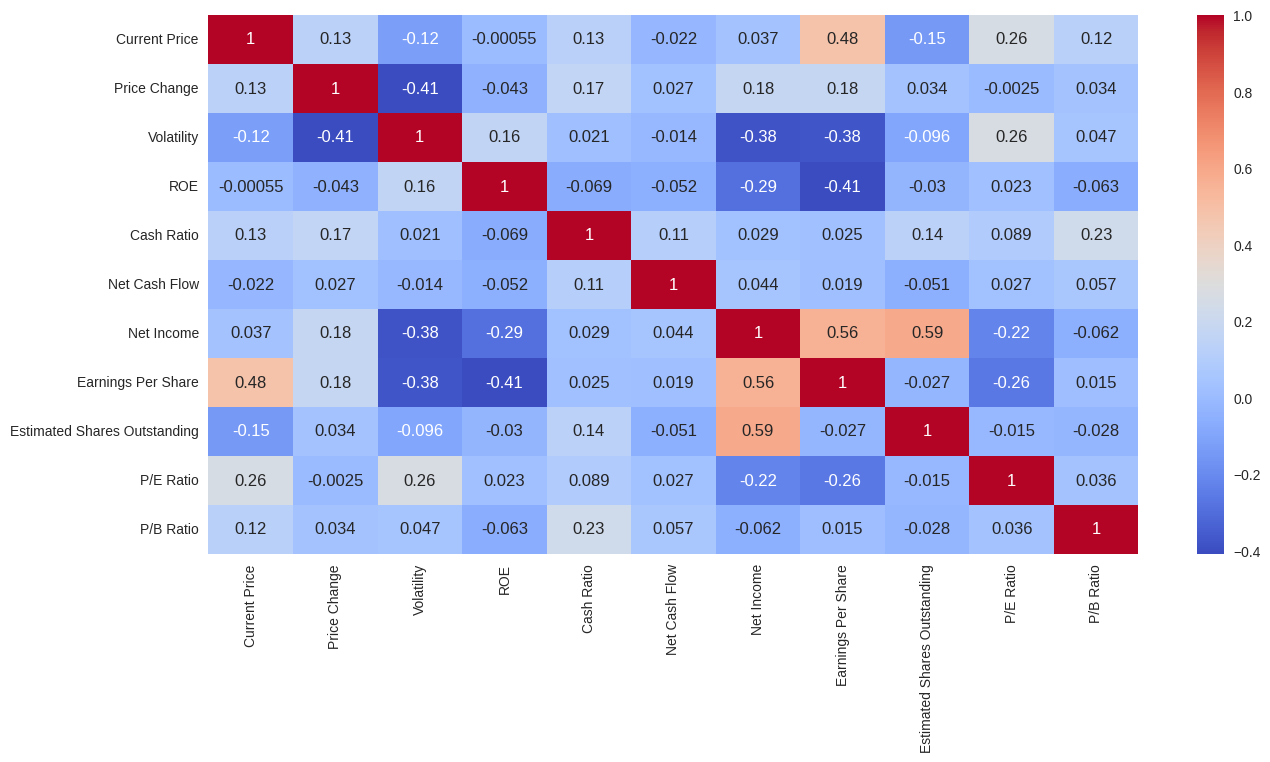

In [16]:
plt.figure(figsize=(15, 7))
sns.heatmap(df[num_col].corr(), annot=True, cmap='coolwarm')
plt.show()

* Moderate correlation only exists between earnings per share and net income and net income and shares outstanding which makes sense. Also it exists between earnings per share and current price but is slighlty lower the other correlations

/tmp/ipykernel_829/1701191014.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(x = 'GICS Sector', y = 'Current Price', data = df, ci=False)


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Industrials'),
  Text(1, 0, 'Health Care'),
  Text(2, 0, 'Information Technology'),
  Text(3, 0, 'Consumer Staples'),
  Text(4, 0, 'Utilities'),
  Text(5, 0, 'Financials'),
  Text(6, 0, 'Real Estate'),
  Text(7, 0, 'Materials'),
  Text(8, 0, 'Consumer Discretionary'),
  Text(9, 0, 'Energy'),
  Text(10, 0, 'Telecommunications Services')])

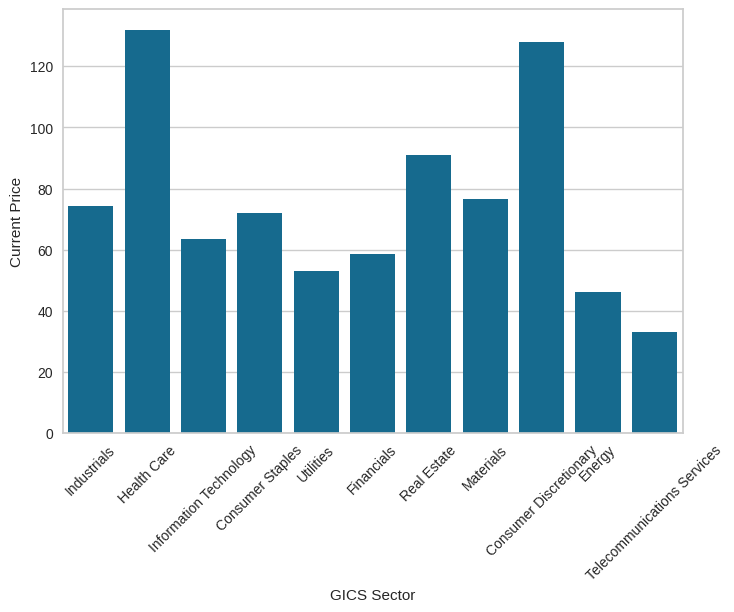

In [17]:
sns.barplot(x = 'GICS Sector', y = 'Current Price', data = df, ci=False)
plt.xticks(rotation=45)

* Healthcare and consumer discretionary sectors have seent seen the greatest price increase

/tmp/ipykernel_829/2928546843.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(x = 'GICS Sector', y = 'Cash Ratio', data = df, ci=False)


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Industrials'),
  Text(1, 0, 'Health Care'),
  Text(2, 0, 'Information Technology'),
  Text(3, 0, 'Consumer Staples'),
  Text(4, 0, 'Utilities'),
  Text(5, 0, 'Financials'),
  Text(6, 0, 'Real Estate'),
  Text(7, 0, 'Materials'),
  Text(8, 0, 'Consumer Discretionary'),
  Text(9, 0, 'Energy'),
  Text(10, 0, 'Telecommunications Services')])

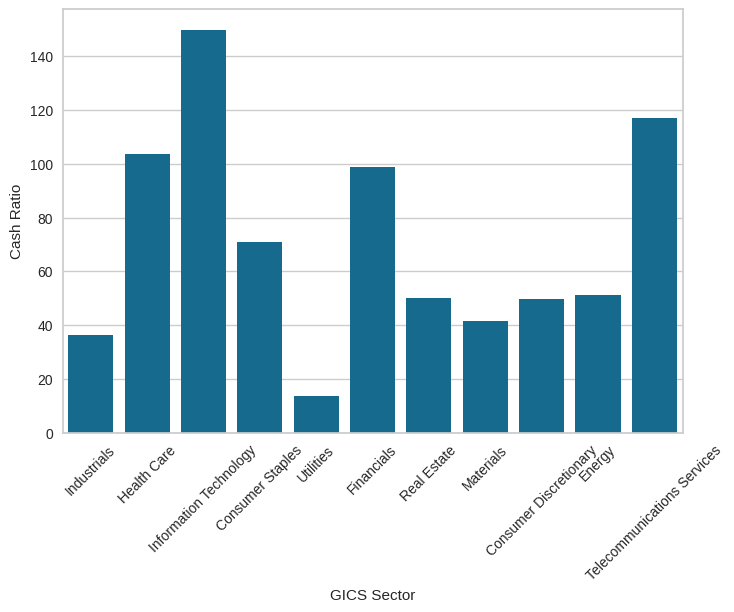

In [18]:
sns.barplot(x = 'GICS Sector', y = 'Cash Ratio', data = df, ci=False)
plt.xticks(rotation=45)

* Information Technology, healthcare, and telecom have highest cash ratios while utilities sector sits at the bottom of cash ratios

/tmp/ipykernel_829/4147321246.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(x = 'GICS Sector', y = 'P/E Ratio', data = df, ci=False)


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Industrials'),
  Text(1, 0, 'Health Care'),
  Text(2, 0, 'Information Technology'),
  Text(3, 0, 'Consumer Staples'),
  Text(4, 0, 'Utilities'),
  Text(5, 0, 'Financials'),
  Text(6, 0, 'Real Estate'),
  Text(7, 0, 'Materials'),
  Text(8, 0, 'Consumer Discretionary'),
  Text(9, 0, 'Energy'),
  Text(10, 0, 'Telecommunications Services')])

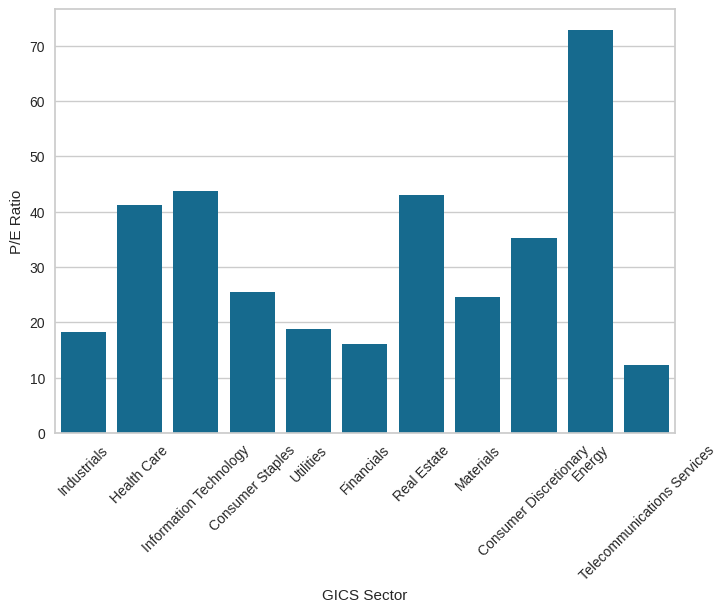

In [19]:
sns.barplot(x = 'GICS Sector', y = 'P/E Ratio', data = df, ci=False)
plt.xticks(rotation=45)

* Energy sector has the highest P/E Ratio

/tmp/ipykernel_829/213798345.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(x = 'GICS Sector', y = 'Net Income', data = df, ci=False)


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Industrials'),
  Text(1, 0, 'Health Care'),
  Text(2, 0, 'Information Technology'),
  Text(3, 0, 'Consumer Staples'),
  Text(4, 0, 'Utilities'),
  Text(5, 0, 'Financials'),
  Text(6, 0, 'Real Estate'),
  Text(7, 0, 'Materials'),
  Text(8, 0, 'Consumer Discretionary'),
  Text(9, 0, 'Energy'),
  Text(10, 0, 'Telecommunications Services')])

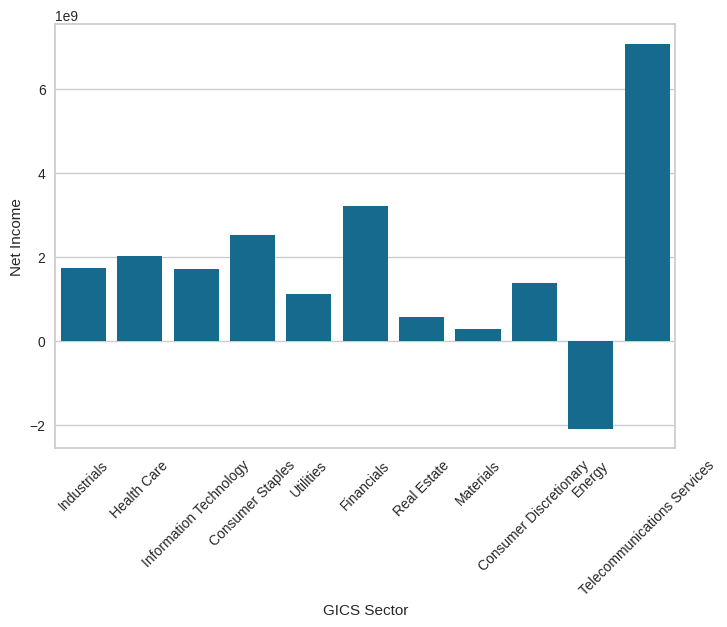

In [20]:
sns.barplot(x = 'GICS Sector', y = 'Net Income', data = df, ci=False)
plt.xticks(rotation=45)

* Telecom has the highest net income while energy sector has a negative net income

/tmp/ipykernel_829/2317906755.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(x = 'GICS Sector', y = 'Volatility', data = df, ci=False)


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Industrials'),
  Text(1, 0, 'Health Care'),
  Text(2, 0, 'Information Technology'),
  Text(3, 0, 'Consumer Staples'),
  Text(4, 0, 'Utilities'),
  Text(5, 0, 'Financials'),
  Text(6, 0, 'Real Estate'),
  Text(7, 0, 'Materials'),
  Text(8, 0, 'Consumer Discretionary'),
  Text(9, 0, 'Energy'),
  Text(10, 0, 'Telecommunications Services')])

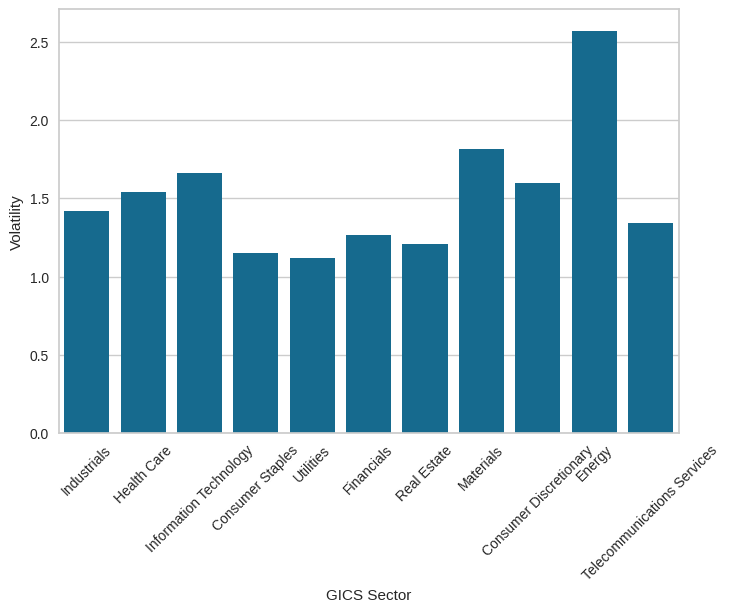

In [21]:
sns.barplot(x = 'GICS Sector', y = 'Volatility', data = df, ci=False)
plt.xticks(rotation=45)

* Energy has the highest volatility

## Data Preprocessing

- Duplicate value check
- Missing value treatment
- Outlier check
- Feature engineering (if needed)
- Any other preprocessing steps (if needed)

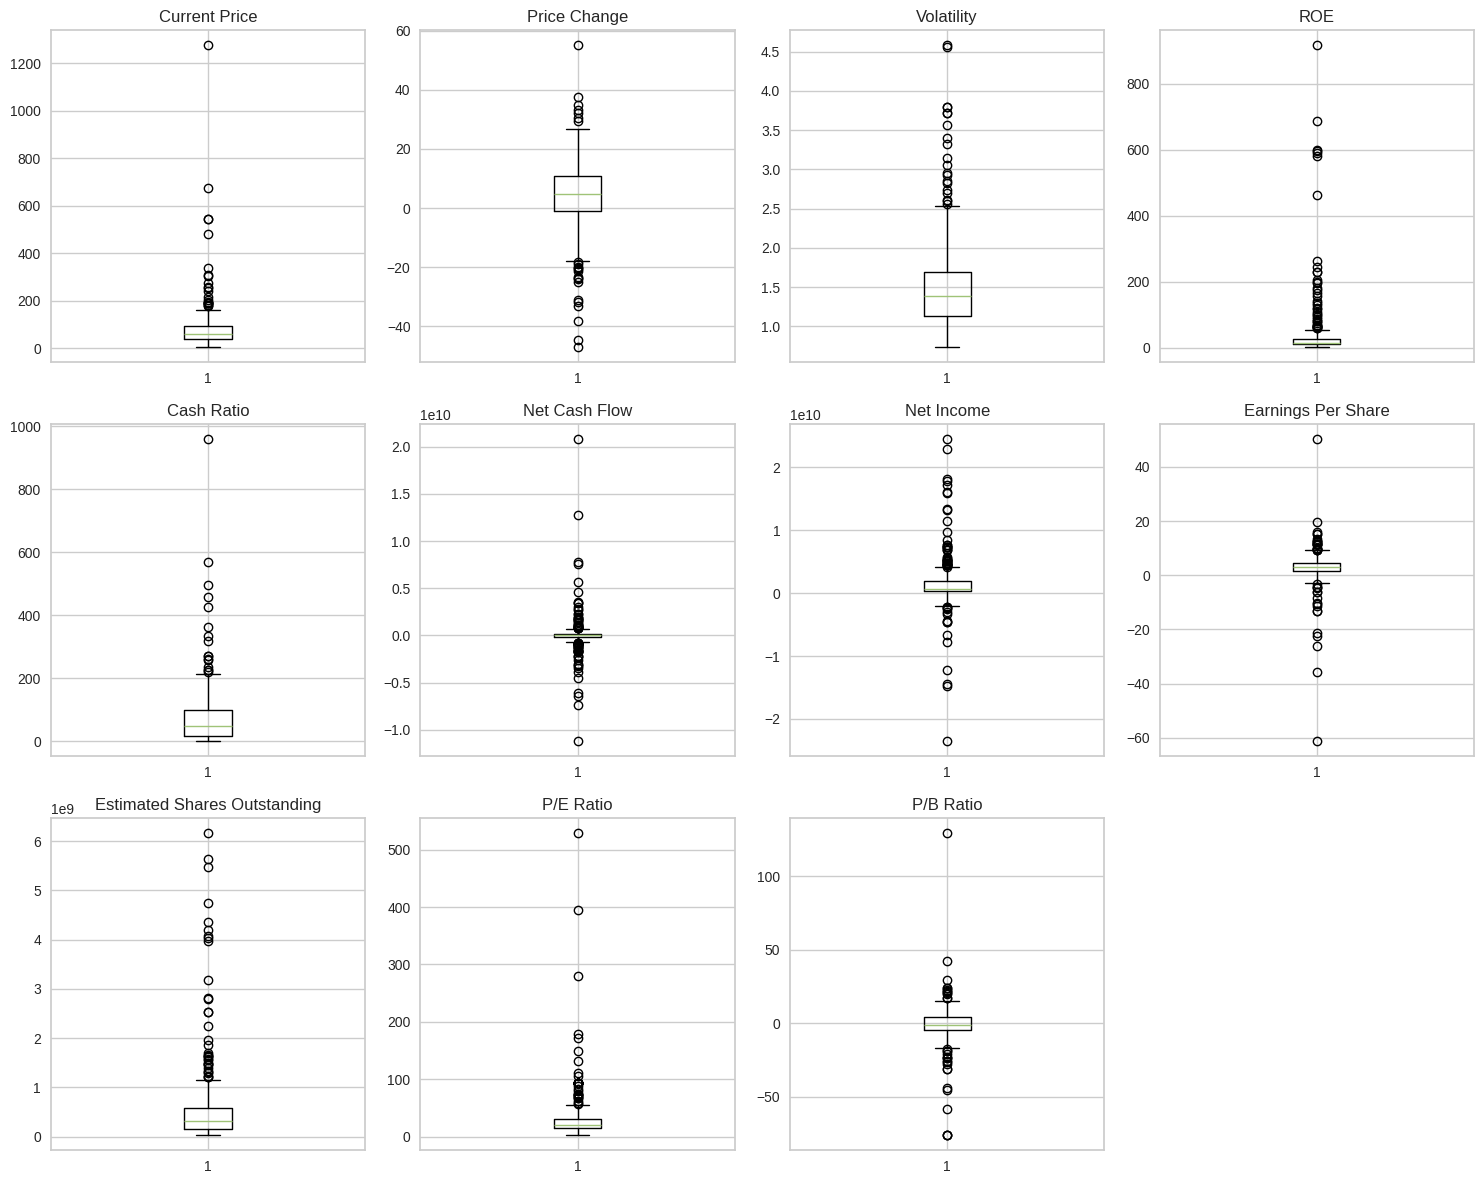

In [22]:
#outlier check to see if outliers are valid
plt.figure(figsize=(15, 12))

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

for i, variable in enumerate(numeric_columns):
    plt.subplot(3, 4, i + 1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

* Outliers look normal and no unusal outliers for what the data inside the columns are but since there are a lot of extreme values I will use winsorization to create more balanced clusters

In [23]:
subset = df[num_col].copy()
winsorized = subset.copy()

for col in winsorized.columns:
    lower = winsorized[col].quantile(0.01)
    upper = winsorized[col].quantile(0.99)
    winsorized[col] = winsorized[col].clip(lower, upper)

# Scaling the winsorized data
scaler = StandardScaler()
scale = scaler.fit_transform(winsorized)
dfs = pd.DataFrame(scale, columns=winsorized.columns)

In [24]:
dfs.sample(n=10, random_state = 1)

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
102,-0.630723,-1.722707,2.468307,1.916206,0.026633,0.600802,-3.488185,-5.133305,-0.203940,2.145194,0.343076
125,0.364760,1.068413,-0.353685,-0.348939,4.968574,0.424585,0.623825,-0.314817,2.851581,1.691920,0.726433
11,-0.520707,0.307233,-0.630538,-0.268452,-0.275876,0.002418,-0.370997,-0.271300,-0.514009,-0.147725,0.057352
248,0.018821,0.578570,-1.214435,-0.245455,0.802634,0.105013,-0.258334,0.093415,-0.095704,-0.225540,-0.034999
238,-0.142846,-0.283816,0.119695,-0.072982,-0.052282,-0.449096,-2.720471,-2.706188,0.253863,2.145194,0.488931
336,-0.349640,-1.125861,-0.075073,1.191819,-0.538927,0.103989,-0.067256,0.029176,-0.167221,-0.444957,-0.182915
112,-0.354930,-2.231206,1.484600,-0.417928,1.749618,0.374092,-0.418564,-0.470235,-0.528729,2.145194,1.070943
147,-0.602774,-0.809162,0.782538,-0.394932,1.591787,5.003261,-0.638503,-0.749988,0.361154,2.145194,1.798396
89,-0.334517,-0.038331,-0.636588,-0.210961,0.408057,1.680316,0.224766,0.478853,-0.152502,-0.693998,0.140910
173,-0.610446,0.262233,0.104414,-0.302946,-0.012825,0.291312,-0.161756,-0.117954,-0.176143,-0.543472,0.570630


## K-means Clustering

In [25]:
#Creating copy of scaled data so no changes happen to the original data
kdf= dfs.copy()

Number of Clusters: 1 	Inertia: 3739.9999999999995
Number of Clusters: 2 	Inertia: 3203.8248892748265
Number of Clusters: 3 	Inertia: 2845.3618732032824
Number of Clusters: 4 	Inertia: 2597.517326274733
Number of Clusters: 5 	Inertia: 2359.112000949736
Number of Clusters: 6 	Inertia: 2201.3353723271475
Number of Clusters: 7 	Inertia: 2148.3714605717737
Number of Clusters: 8 	Inertia: 1914.1019058642664
Number of Clusters: 9 	Inertia: 1881.9325441817039
Number of Clusters: 10 	Inertia: 1799.9857943747836


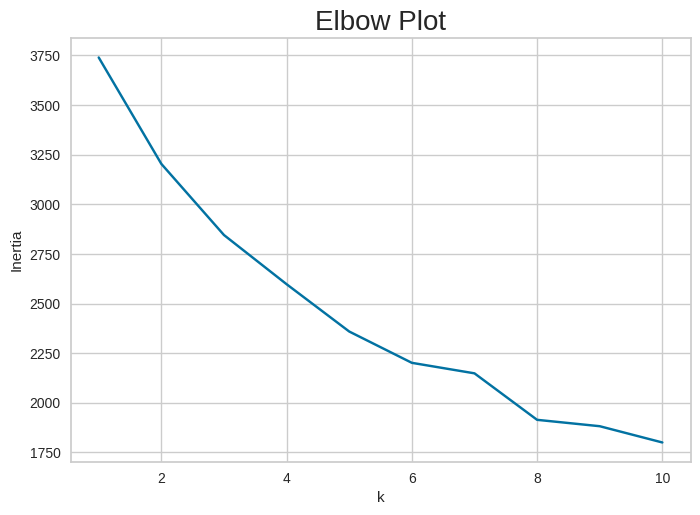

In [26]:
#Creating elbow plot
clusters = range(1, 11)
inertias = []

for k in clusters:
  model = KMeans(n_clusters=k, random_state=1)
  model.fit(dfs)
  inertias.append(model.inertia_)
  print("Number of Clusters:", k, "\tInertia:", model.inertia_)

plt.plot(clusters, inertias, "bx-")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Plot", fontsize=20)
plt.show()

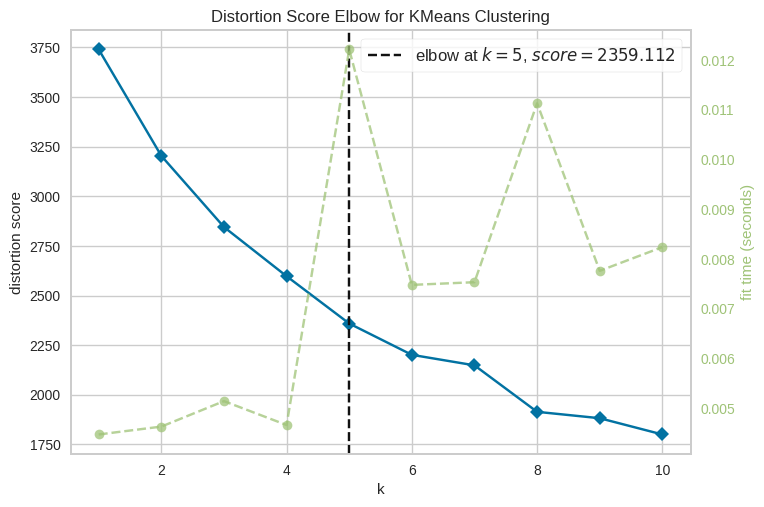

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [27]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(1, 11), timings=True)
visualizer.fit(kdf)
visualizer.show()

* From both graphs, 4 or 5 would be the chosen k value

For n_clusters = 2, silhouette score is 0.3959001001858345
For n_clusters = 3, silhouette score is 0.4122050439813112
For n_clusters = 4, silhouette score is 0.3222254087810077
For n_clusters = 5, silhouette score is 0.3587165582153666
For n_clusters = 6, silhouette score is 0.17855653376342007
For n_clusters = 7, silhouette score is 0.17826002364171098
For n_clusters = 8, silhouette score is 0.1934801147386258
For n_clusters = 9, silhouette score is 0.11353321803975845
For n_clusters = 10, silhouette score is 0.11670621876362625


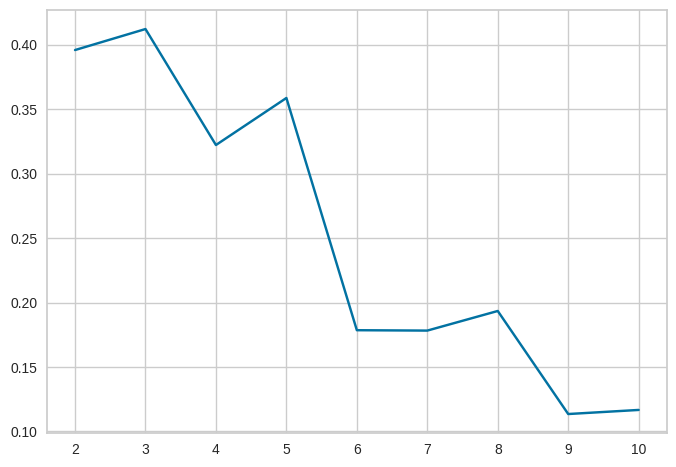

In [28]:
# Checking the silouette scores
sil_score = []
cluster_list = list(range(2, 11))
for n_clusters in cluster_list:
  clusterer = KMeans(n_clusters=n_clusters, random_state = 1)
  preds = clusterer.fit_predict((dfs))
  score = silhouette_score(dfs, preds)
  sil_score.append(score)
  print("For n_clusters = {}, silhouette score is {}".format(n_clusters, score))
plt.plot(cluster_list, sil_score)

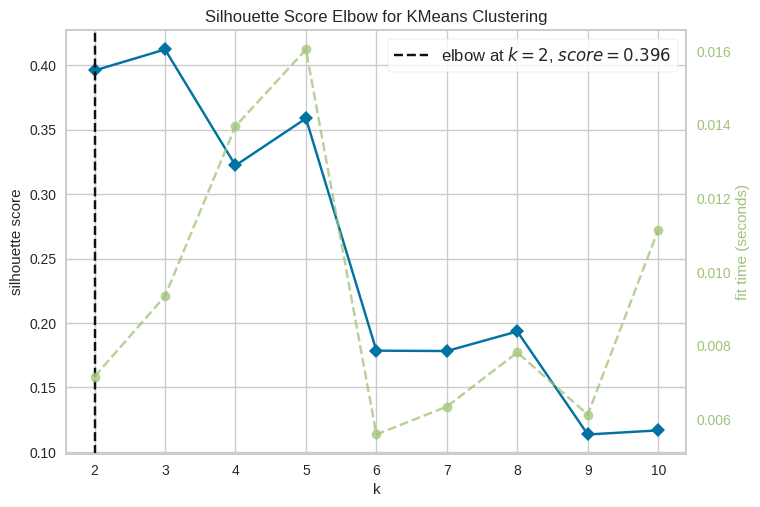

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [29]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2, 11), metric="silhouette", timings=True)
visualizer.fit(kdf)
visualizer.show()

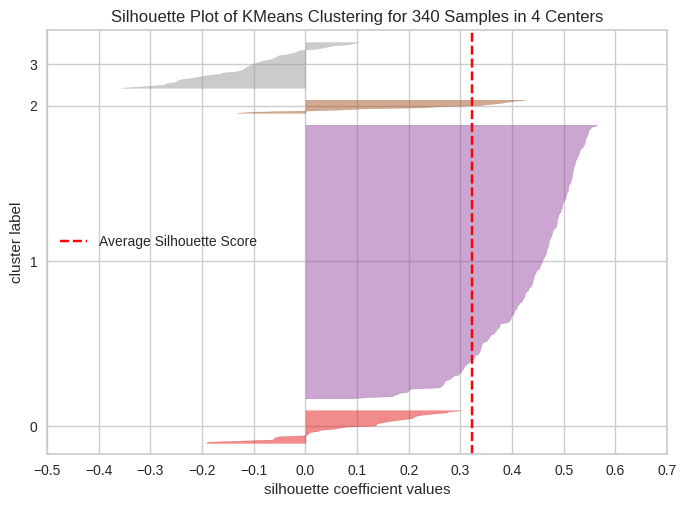

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [30]:
visualizer = SilhouetteVisualizer(KMeans(n_clusters= 4, random_state=1))
visualizer.fit(kdf)
visualizer.show()

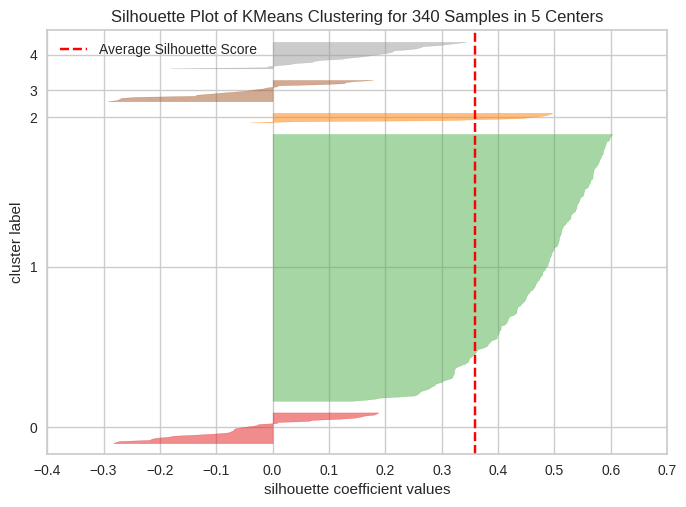

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [31]:
visualizer = SilhouetteVisualizer(KMeans(n_clusters= 5, random_state=1))
visualizer.fit(kdf)
visualizer.show()

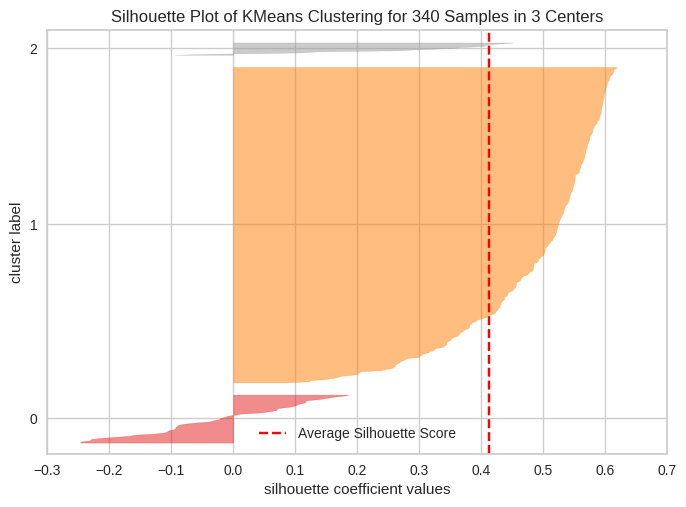

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [32]:
visualizer = SilhouetteVisualizer(KMeans(n_clusters= 3, random_state=1))  ## Complete the code to visualize the silhouette scores for certain number of clusters
visualizer.fit(kdf)
visualizer.show()

* Going to choose 4 as my k since it sits in between the elbow and silhouette scores

In [33]:
# Creating final k means model
kmeans = KMeans(n_clusters=4 , random_state=1)
kmeans.fit(kdf)

KMeans(n_clusters=4, random_state=1)

In [34]:
# Adding Labels to Dataframe
df1 = data.copy()
kdf["KM_segments"] = kmeans.labels_
df1["KM_segments"] = kmeans.labels_

In [35]:
df1.sample(n=15, random_state=1)

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,KM_segments
102,DVN,Devon Energy Corp.,Energy,Oil & Gas Exploration & Production,32.000000,-15.478079,2.923698,205,70,830000000,-14454000000,-35.55,4.065823e+08,93.089287,1.785616,0
125,FB,Facebook,Information Technology,Internet Software & Services,104.660004,16.224320,1.320606,8,958,592000000,3669000000,1.31,2.800763e+09,79.893133,5.884467,1
11,AIV,Apartment Investment & Mgmt,Real Estate,REITs,40.029999,7.578608,1.163334,15,47,21818000,248710000,1.52,1.636250e+08,26.335526,-1.269332,1
248,PG,Procter & Gamble,Consumer Staples,Personal Products,79.410004,10.660538,0.806056,17,129,160383000,636056000,3.28,4.913916e+08,24.070121,-2.256747,1
238,OXY,Occidental Petroleum,Energy,Oil & Gas Exploration & Production,67.610001,0.865287,1.589520,32,64,-588000000,-7829000000,-10.23,7.652981e+08,93.089287,3.345102,0
336,YUM,Yum! Brands Inc,Consumer Discretionary,Restaurants,52.516175,-8.698917,1.478877,142,27,159000000,1293000000,2.97,4.353535e+08,17.682214,-3.838260,1
112,EQT,EQT Corporation,Energy,Oil & Gas Exploration & Production,52.130001,-21.253771,2.364883,2,201,523803000,85171000,0.56,1.520911e+08,93.089287,9.567952,0
147,HAL,Halliburton Co.,Energy,Oil & Gas Equipment & Services,34.040001,-5.101751,1.966062,4,189,7786000000,-671000000,-0.79,8.493671e+08,93.089287,17.345857,0
89,DFS,Discover Financial Services,Financials,Consumer Finance,53.619999,3.653584,1.159897,20,99,2288000000,2297000000,5.14,4.468872e+08,10.431906,-0.375934,1
173,IVZ,Invesco Ltd.,Financials,Asset Management & Custody Banks,33.480000,7.067477,1.580839,12,67,412000000,968100000,2.26,4.283628e+08,14.814159,4.218620,1


Cluster Profiling

In [36]:
kprof = df1.groupby("KM_segments").mean(numeric_only=True)

In [37]:
kprof["count_in_each_segment"] = (
    df1.groupby("KM_segments")["Security"].count().values  ## Complete the code to groupby the cluster labels
)

In [38]:
#Finding max values of each cluster
kprof.style.highlight_max(color="blue", axis=0)

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,count_in_each_segment
KM_segments,,,,,,,,,,,,
0,39.070000,-12.978398,2.841171,99.548387,65.032258,119112129.032258,-3372393258.064516,-8.195161,543392603.256129,91.505204,2.088928,31
1,62.972558,5.647944,1.405421,24.395257,71.308300,112499442.687747,1490720383.399209,3.281245,478393537.820119,22.330867,-0.666061,253
2,55.947692,5.400968,1.143214,35.230769,68.615385,-1264769230.769231,14310846153.846153,5.022308,3834693329.069231,13.739602,-3.854843,13
3,223.782557,6.738929,1.402844,87.139535,66.488372,73719906.976744,1149806953.488372,7.038837,196741529.977674,56.355490,-10.007797,43


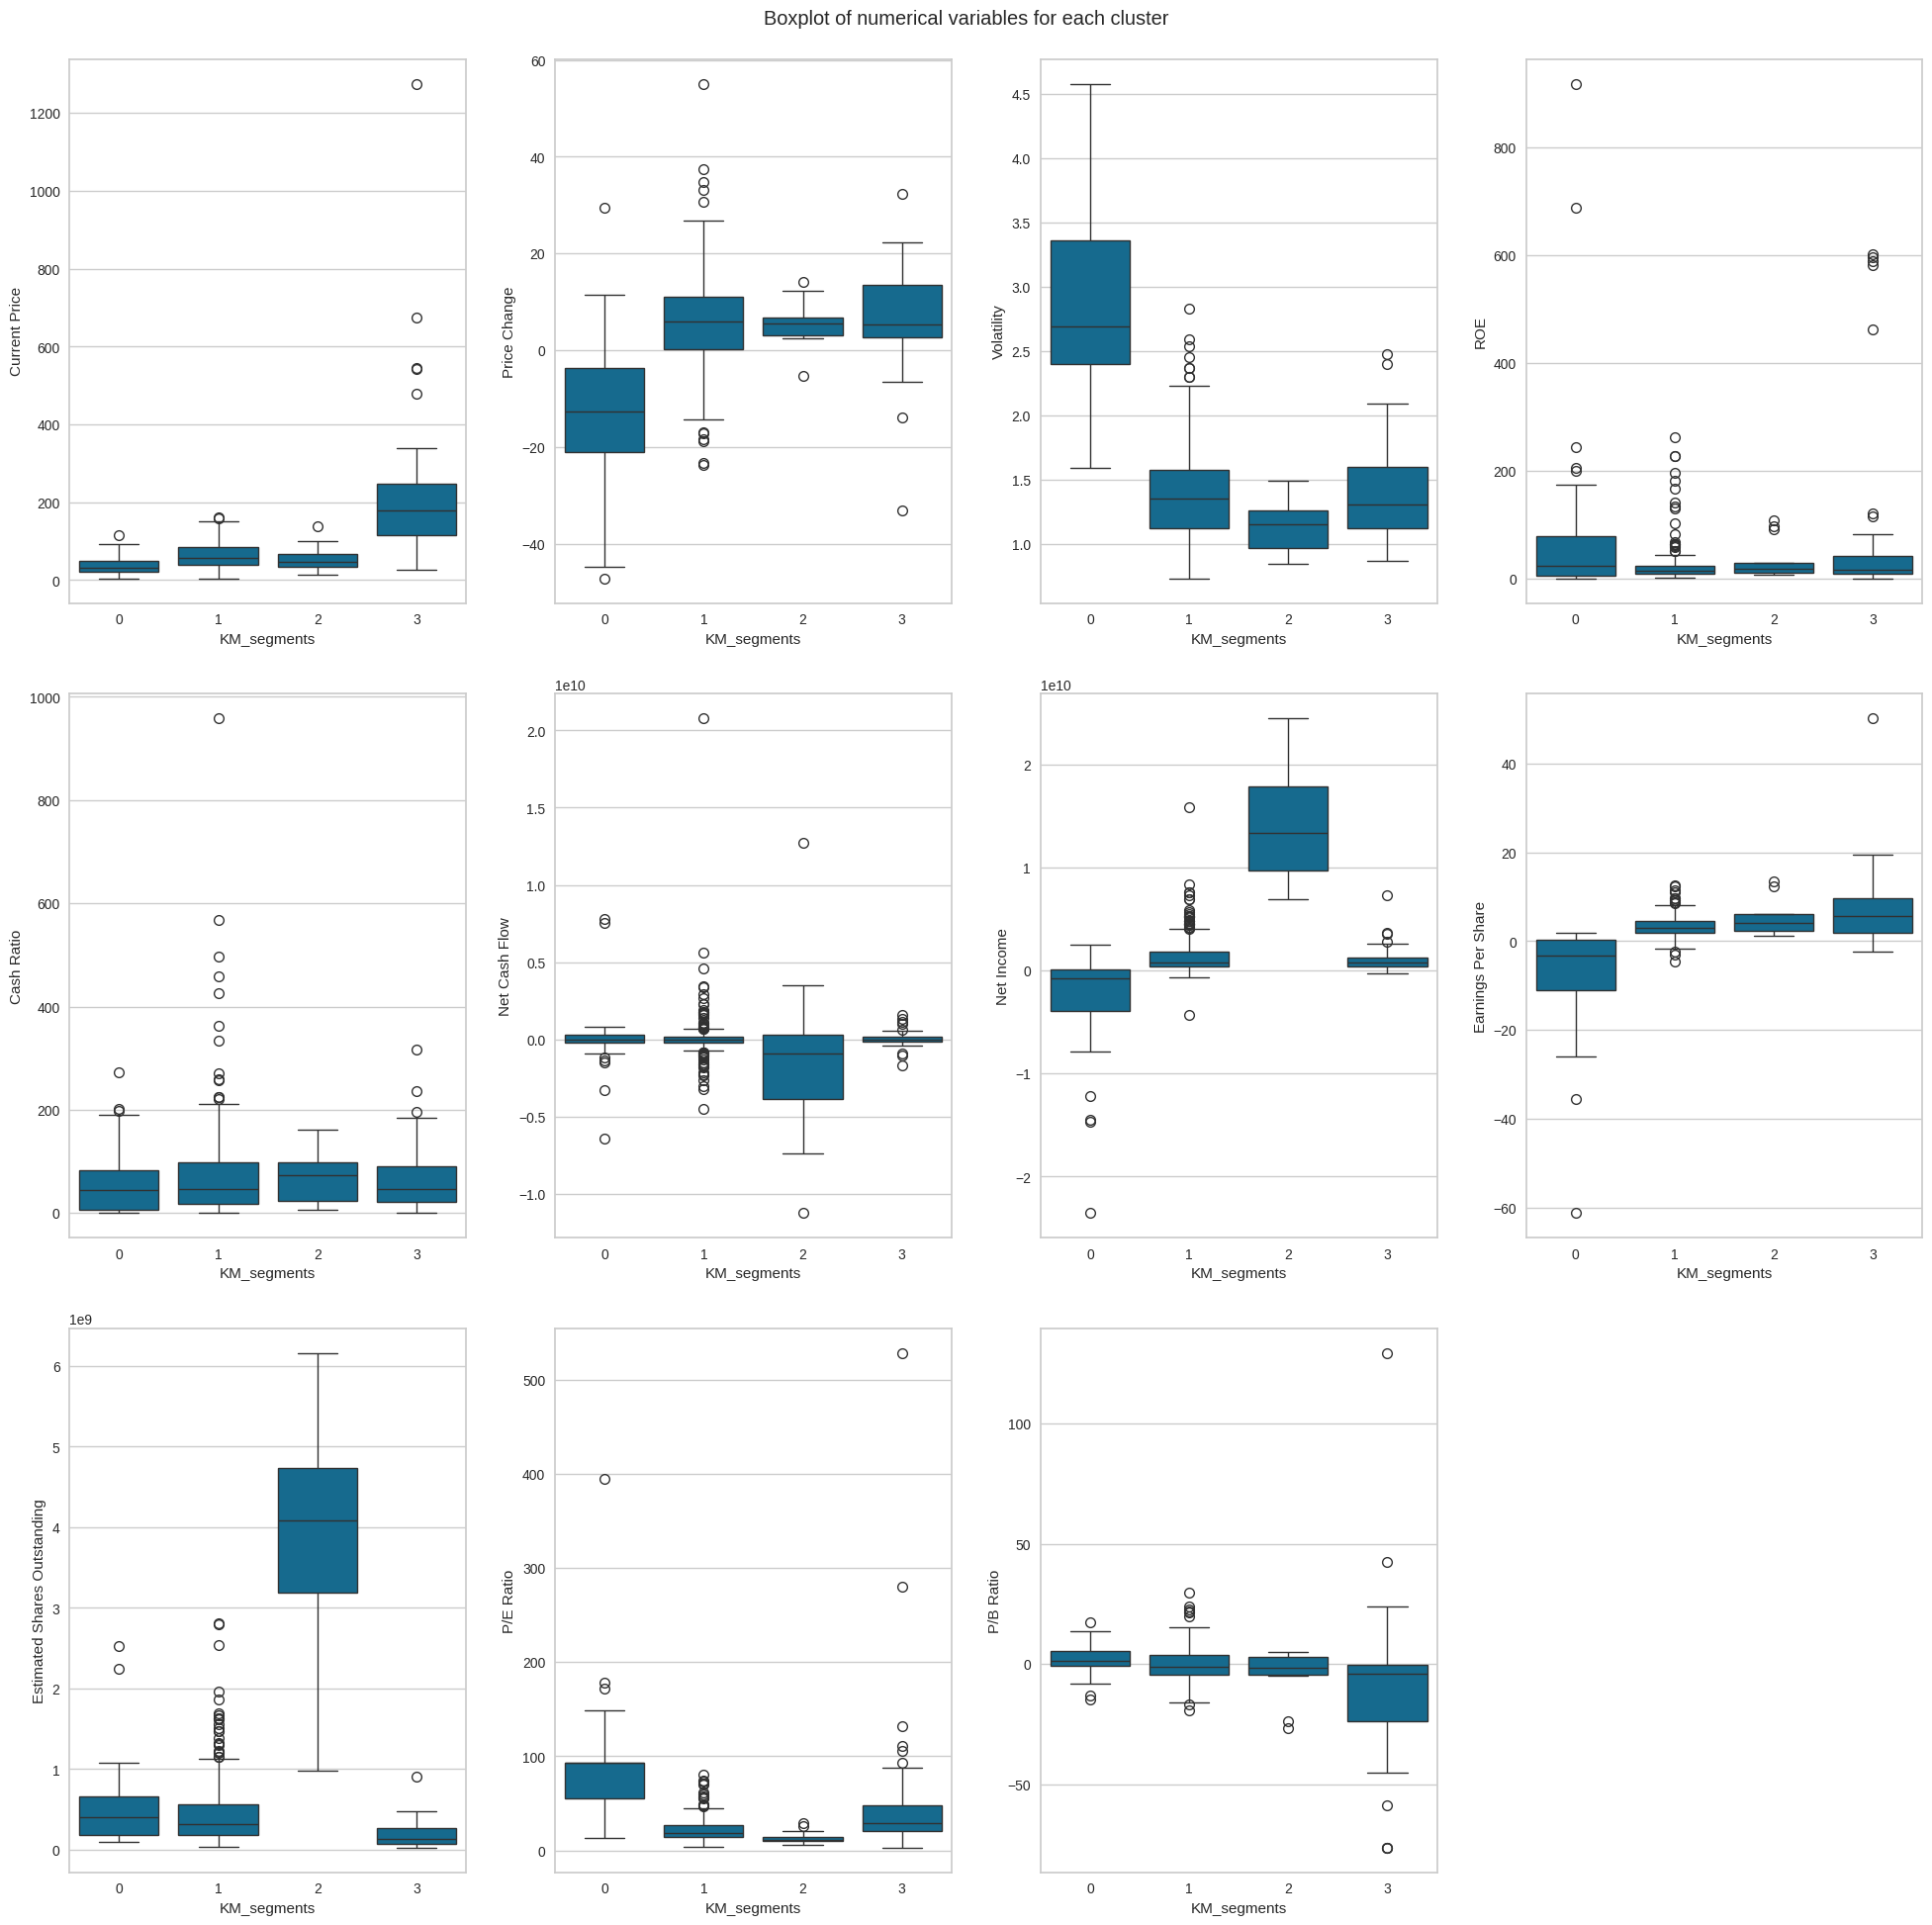

In [39]:
# Boxplots of each columns clusters
plt.figure(figsize=(20, 20))
plt.suptitle("Boxplot of numerical variables for each cluster")

num_col = df.select_dtypes(include=np.number).columns.tolist()

for i, variable in enumerate(num_col):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(data=df1, x="KM_segments", y=variable)

plt.tight_layout(pad=2.0)

### Insights


*   Cluster 0 :Lowest Current Price, High Volatility, High ROE, Negative Net Income/EPS


*   Cluster 1 :Mid-Range Current Price, Moderate Performance, Balanced Metrics
  

*   Cluster 2 :Low Volatility, Stable, Moderate Net Income
    

*   Cluster 3 :Highest Current Price, High Net Income, High Shares Outstanding
  

## Hierarchical Clustering

In [40]:
hdf = dfs.copy()

In [41]:
# list of distance metrics
distance_metrics = ["euclidean","chebyshev","mahalanobis","cityblock"]
# list of linkage methods
linkage_methods = ["single","complete","average","weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(hdf, metric=dm, method=lm)
        c, coph_dists = cophenet(Z, pdist(hdf))
        print(
            "Cophenetic correlation for {} distance and {} linkage is {}.".format(
                dm.capitalize(), lm, c
            )
        )
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm[0] = dm
            high_dm_lm[1] = lm

Cophenetic correlation for Euclidean distance and single linkage is 0.8971278890100828.
Cophenetic correlation for Euclidean distance and complete linkage is 0.7806656690819611.
Cophenetic correlation for Euclidean distance and average linkage is 0.9139539550341494.
Cophenetic correlation for Euclidean distance and weighted linkage is 0.8512722656811862.
Cophenetic correlation for Chebyshev distance and single linkage is 0.8926651148727601.
Cophenetic correlation for Chebyshev distance and complete linkage is 0.705663303017319.
Cophenetic correlation for Chebyshev distance and average linkage is 0.9024617554561276.
Cophenetic correlation for Chebyshev distance and weighted linkage is 0.824520724996218.
Cophenetic correlation for Mahalanobis distance and single linkage is 0.890181856541293.
Cophenetic correlation for Mahalanobis distance and complete linkage is 0.76791957361653.
Cophenetic correlation for Mahalanobis distance and average linkage is 0.8847197457829182.
Cophenetic correla

* Highest correlation is euclidean distance and average linkage: 0.9139539550341494

In [42]:
# Checking euclidean distance and its linkage methods
linkage_methods = ["single","complete","average","centroid","ward","weighted"] ## Complete the code to add linkages

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for lm in linkage_methods:
    Z = linkage(hdf, metric="euclidean", method=lm)
    c, coph_dists = cophenet(Z, pdist(hdf))
    print("Cophenetic correlation for {} linkage is {}.".format(lm, c))
    if high_cophenet_corr < c:
        high_cophenet_corr = c
        high_dm_lm[0] = "euclidean"
        high_dm_lm[1] = lm

Cophenetic correlation for single linkage is 0.8971278890100828.
Cophenetic correlation for complete linkage is 0.7806656690819611.
Cophenetic correlation for average linkage is 0.9139539550341494.
Cophenetic correlation for centroid linkage is 0.910921076042303.
Cophenetic correlation for ward linkage is 0.7393383488878658.
Cophenetic correlation for weighted linkage is 0.8512722656811862.


* Highest correlation is with the average linkage method: 0.9139539550341494

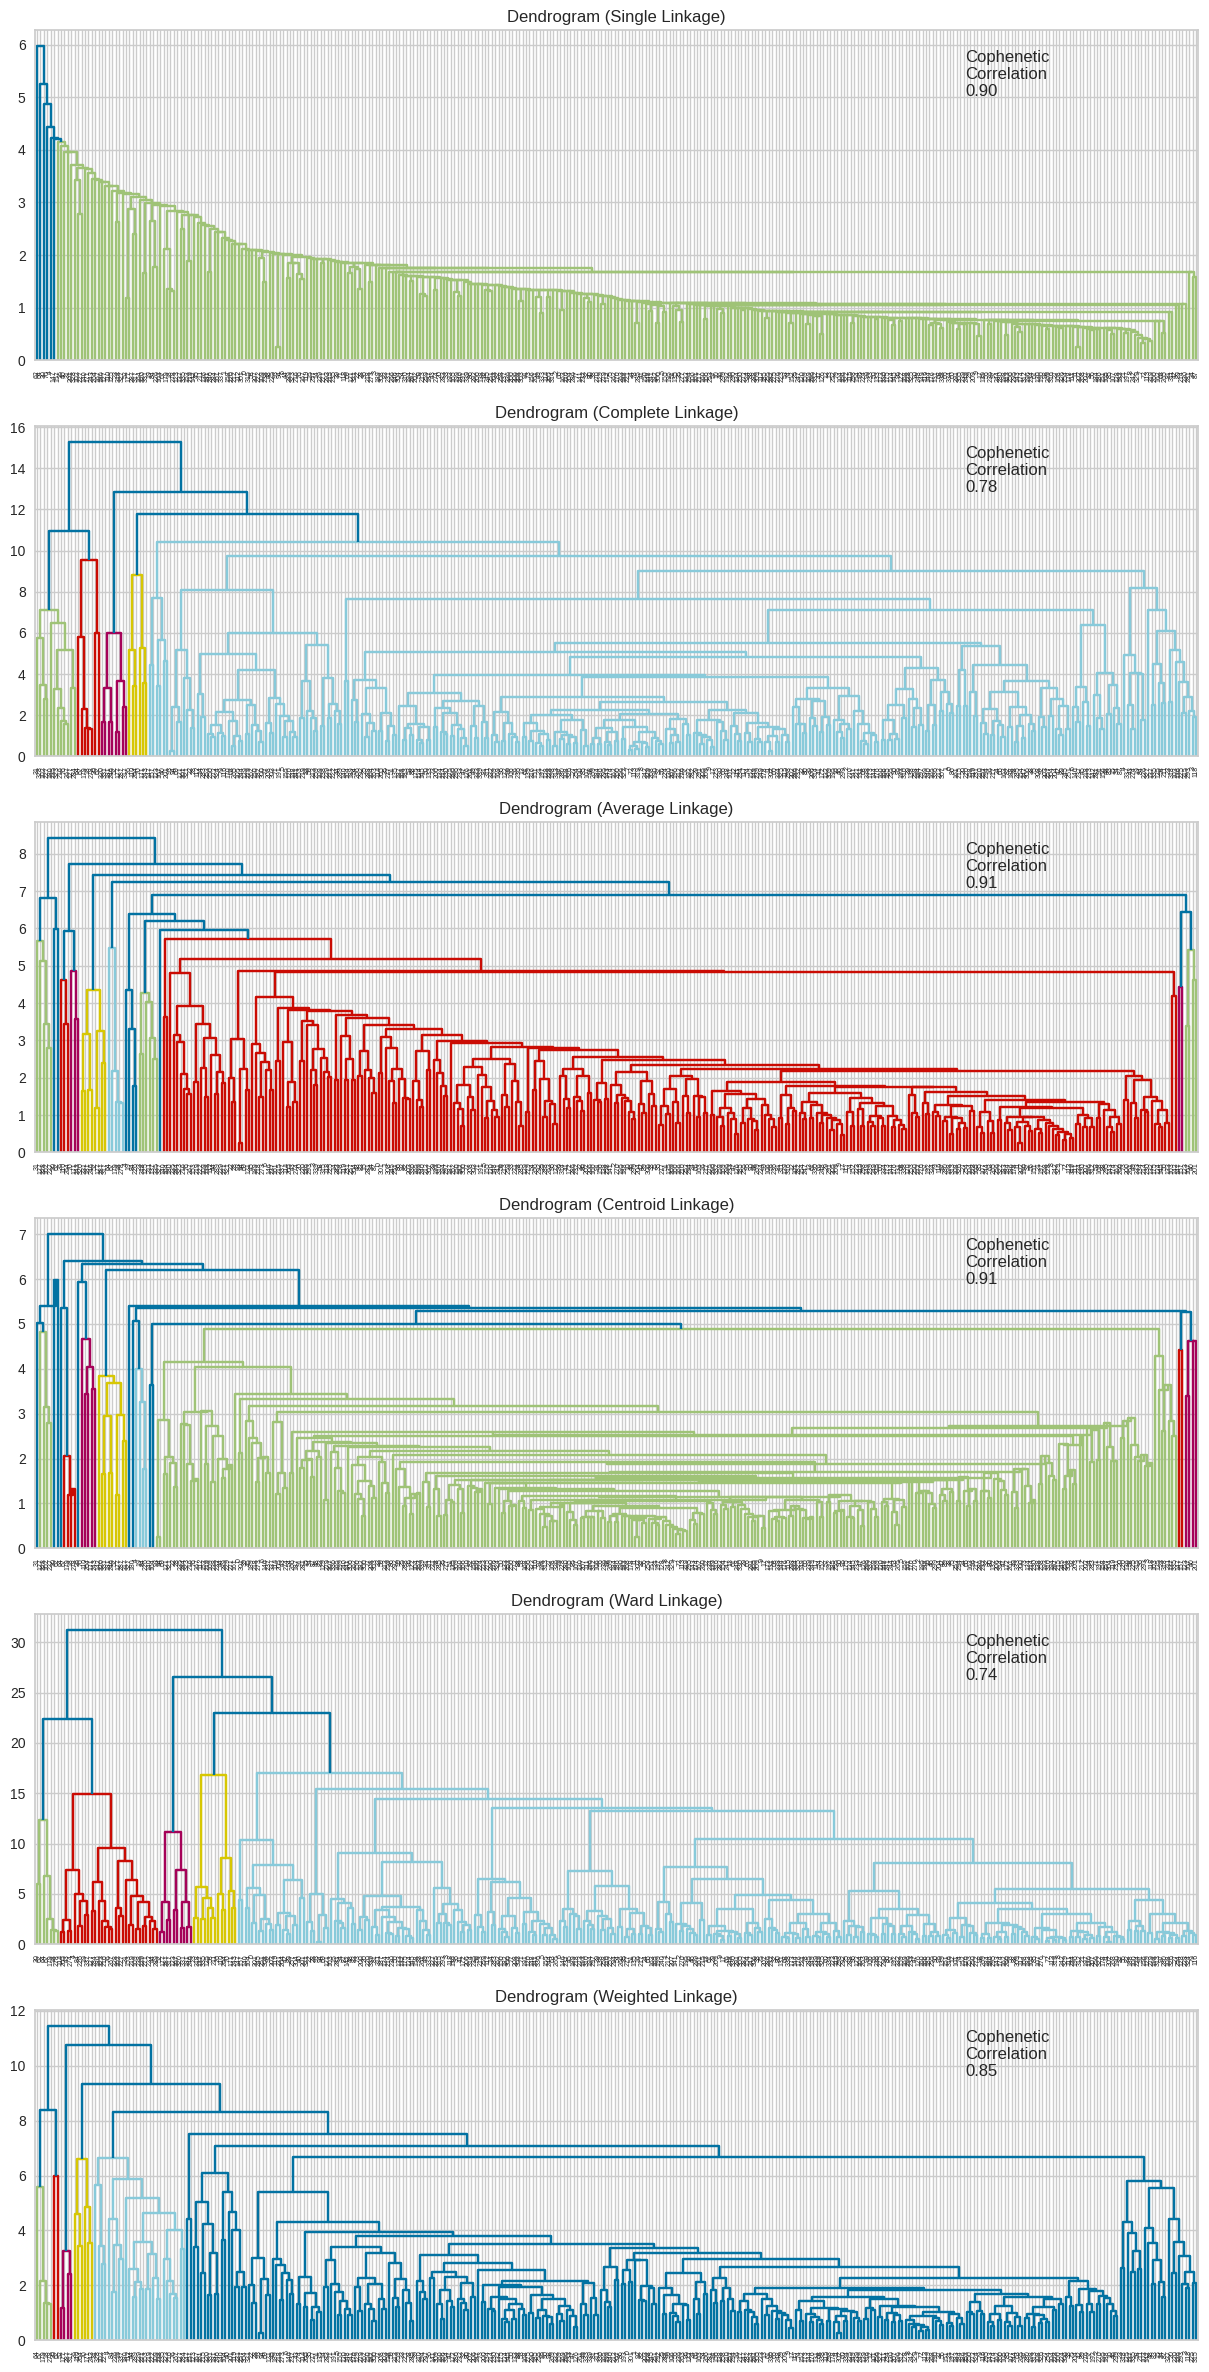

In [43]:
# Visualizing Dendrograms for Euclidean distance and linkage methods
linkage_methods = ["single","complete","average","centroid","ward","weighted"]
compare_cols = ["Linkage", "Cophenetic Coefficient"]
compare = []

fig, axs = plt.subplots(len(linkage_methods), 1, figsize=(15, 30))

for i, method in enumerate(linkage_methods):
    Z = linkage(hdf, metric="euclidean", method=method)

    dendrogram(Z, ax=axs[i])
    axs[i].set_title(f"Dendrogram ({method.capitalize()} Linkage)")

    coph_corr, coph_dist = cophenet(Z, pdist(hdf))
    axs[i].annotate(
        f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
        (0.80, 0.80),
        xycoords="axes fraction",
    )

    compare.append([method, coph_corr])

* Ward linkage has the most distinct clusters
* Going to go forward with ward linkage and euclidean distance because easier to interpret

In [44]:
# Creating final model for Hierarchical clustering
HCmodel = AgglomerativeClustering(n_clusters=5, metric="euclidean", linkage="ward")
HCmodel.fit(hdf)

AgglomerativeClustering(n_clusters=5)

In [45]:
# Adding labels to model data frame
df2 = df.copy()
hdf["HC_segments"] = HCmodel.labels_
df2["HC_segments"] = HCmodel.labels_

In [46]:
df2.sample(n=15, random_state=1)

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,HC_segments
102,DVN,Devon Energy Corp.,Energy,Oil & Gas Exploration & Production,32.000000,-15.478079,2.923698,205,70,830000000,-14454000000,-35.55,4.065823e+08,93.089287,1.785616,3
125,FB,Facebook,Information Technology,Internet Software & Services,104.660004,16.224320,1.320606,8,958,592000000,3669000000,1.31,2.800763e+09,79.893133,5.884467,1
11,AIV,Apartment Investment & Mgmt,Real Estate,REITs,40.029999,7.578608,1.163334,15,47,21818000,248710000,1.52,1.636250e+08,26.335526,-1.269332,0
248,PG,Procter & Gamble,Consumer Staples,Personal Products,79.410004,10.660538,0.806056,17,129,160383000,636056000,3.28,4.913916e+08,24.070121,-2.256747,0
238,OXY,Occidental Petroleum,Energy,Oil & Gas Exploration & Production,67.610001,0.865287,1.589520,32,64,-588000000,-7829000000,-10.23,7.652981e+08,93.089287,3.345102,3
336,YUM,Yum! Brands Inc,Consumer Discretionary,Restaurants,52.516175,-8.698917,1.478877,142,27,159000000,1293000000,2.97,4.353535e+08,17.682214,-3.838260,0
112,EQT,EQT Corporation,Energy,Oil & Gas Exploration & Production,52.130001,-21.253771,2.364883,2,201,523803000,85171000,0.56,1.520911e+08,93.089287,9.567952,0
147,HAL,Halliburton Co.,Energy,Oil & Gas Equipment & Services,34.040001,-5.101751,1.966062,4,189,7786000000,-671000000,-0.79,8.493671e+08,93.089287,17.345857,0
89,DFS,Discover Financial Services,Financials,Consumer Finance,53.619999,3.653584,1.159897,20,99,2288000000,2297000000,5.14,4.468872e+08,10.431906,-0.375934,0
173,IVZ,Invesco Ltd.,Financials,Asset Management & Custody Banks,33.480000,7.067477,1.580839,12,67,412000000,968100000,2.26,4.283628e+08,14.814159,4.218620,0


Cluster Profiling

In [47]:
hprof = df2.groupby("HC_segments").mean(numeric_only=True)

In [48]:
hprof["count_in_each_segment"] = (
    df2.groupby("HC_segments")["Security"].count().values
)

In [49]:
# Finding max values for each cluster
hprof.style.highlight_max(color="blue", axis=0)

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,count_in_each_segment
HC_segments,,,,,,,,,,,,
0,71.337665,5.140561,1.432775,26.099644,58.569395,150049174.377224,1606818918.149466,3.715356,442985097.578434,22.719868,-2.110025,281
1,340.848713,9.786470,1.607183,15.769231,360.769231,326065615.384615,1054330461.538462,8.378462,635765897.590000,80.749866,13.355322,13
2,45.450000,6.053419,1.094033,24.400000,68.700000,-1461900000.000000,14505600000.000000,3.333000,4582322872.800000,15.465907,-5.323276,10
3,67.975518,-9.401894,2.468787,42.931034,59.931034,-307657931.034483,-2324501620.689655,-5.734828,511567371.208965,110.468600,-1.053367,29
4,84.355716,3.854981,1.827670,633.571429,33.571429,-568400000.000000,-4968157142.857142,-10.841429,398169036.442857,42.284541,-11.589502,7


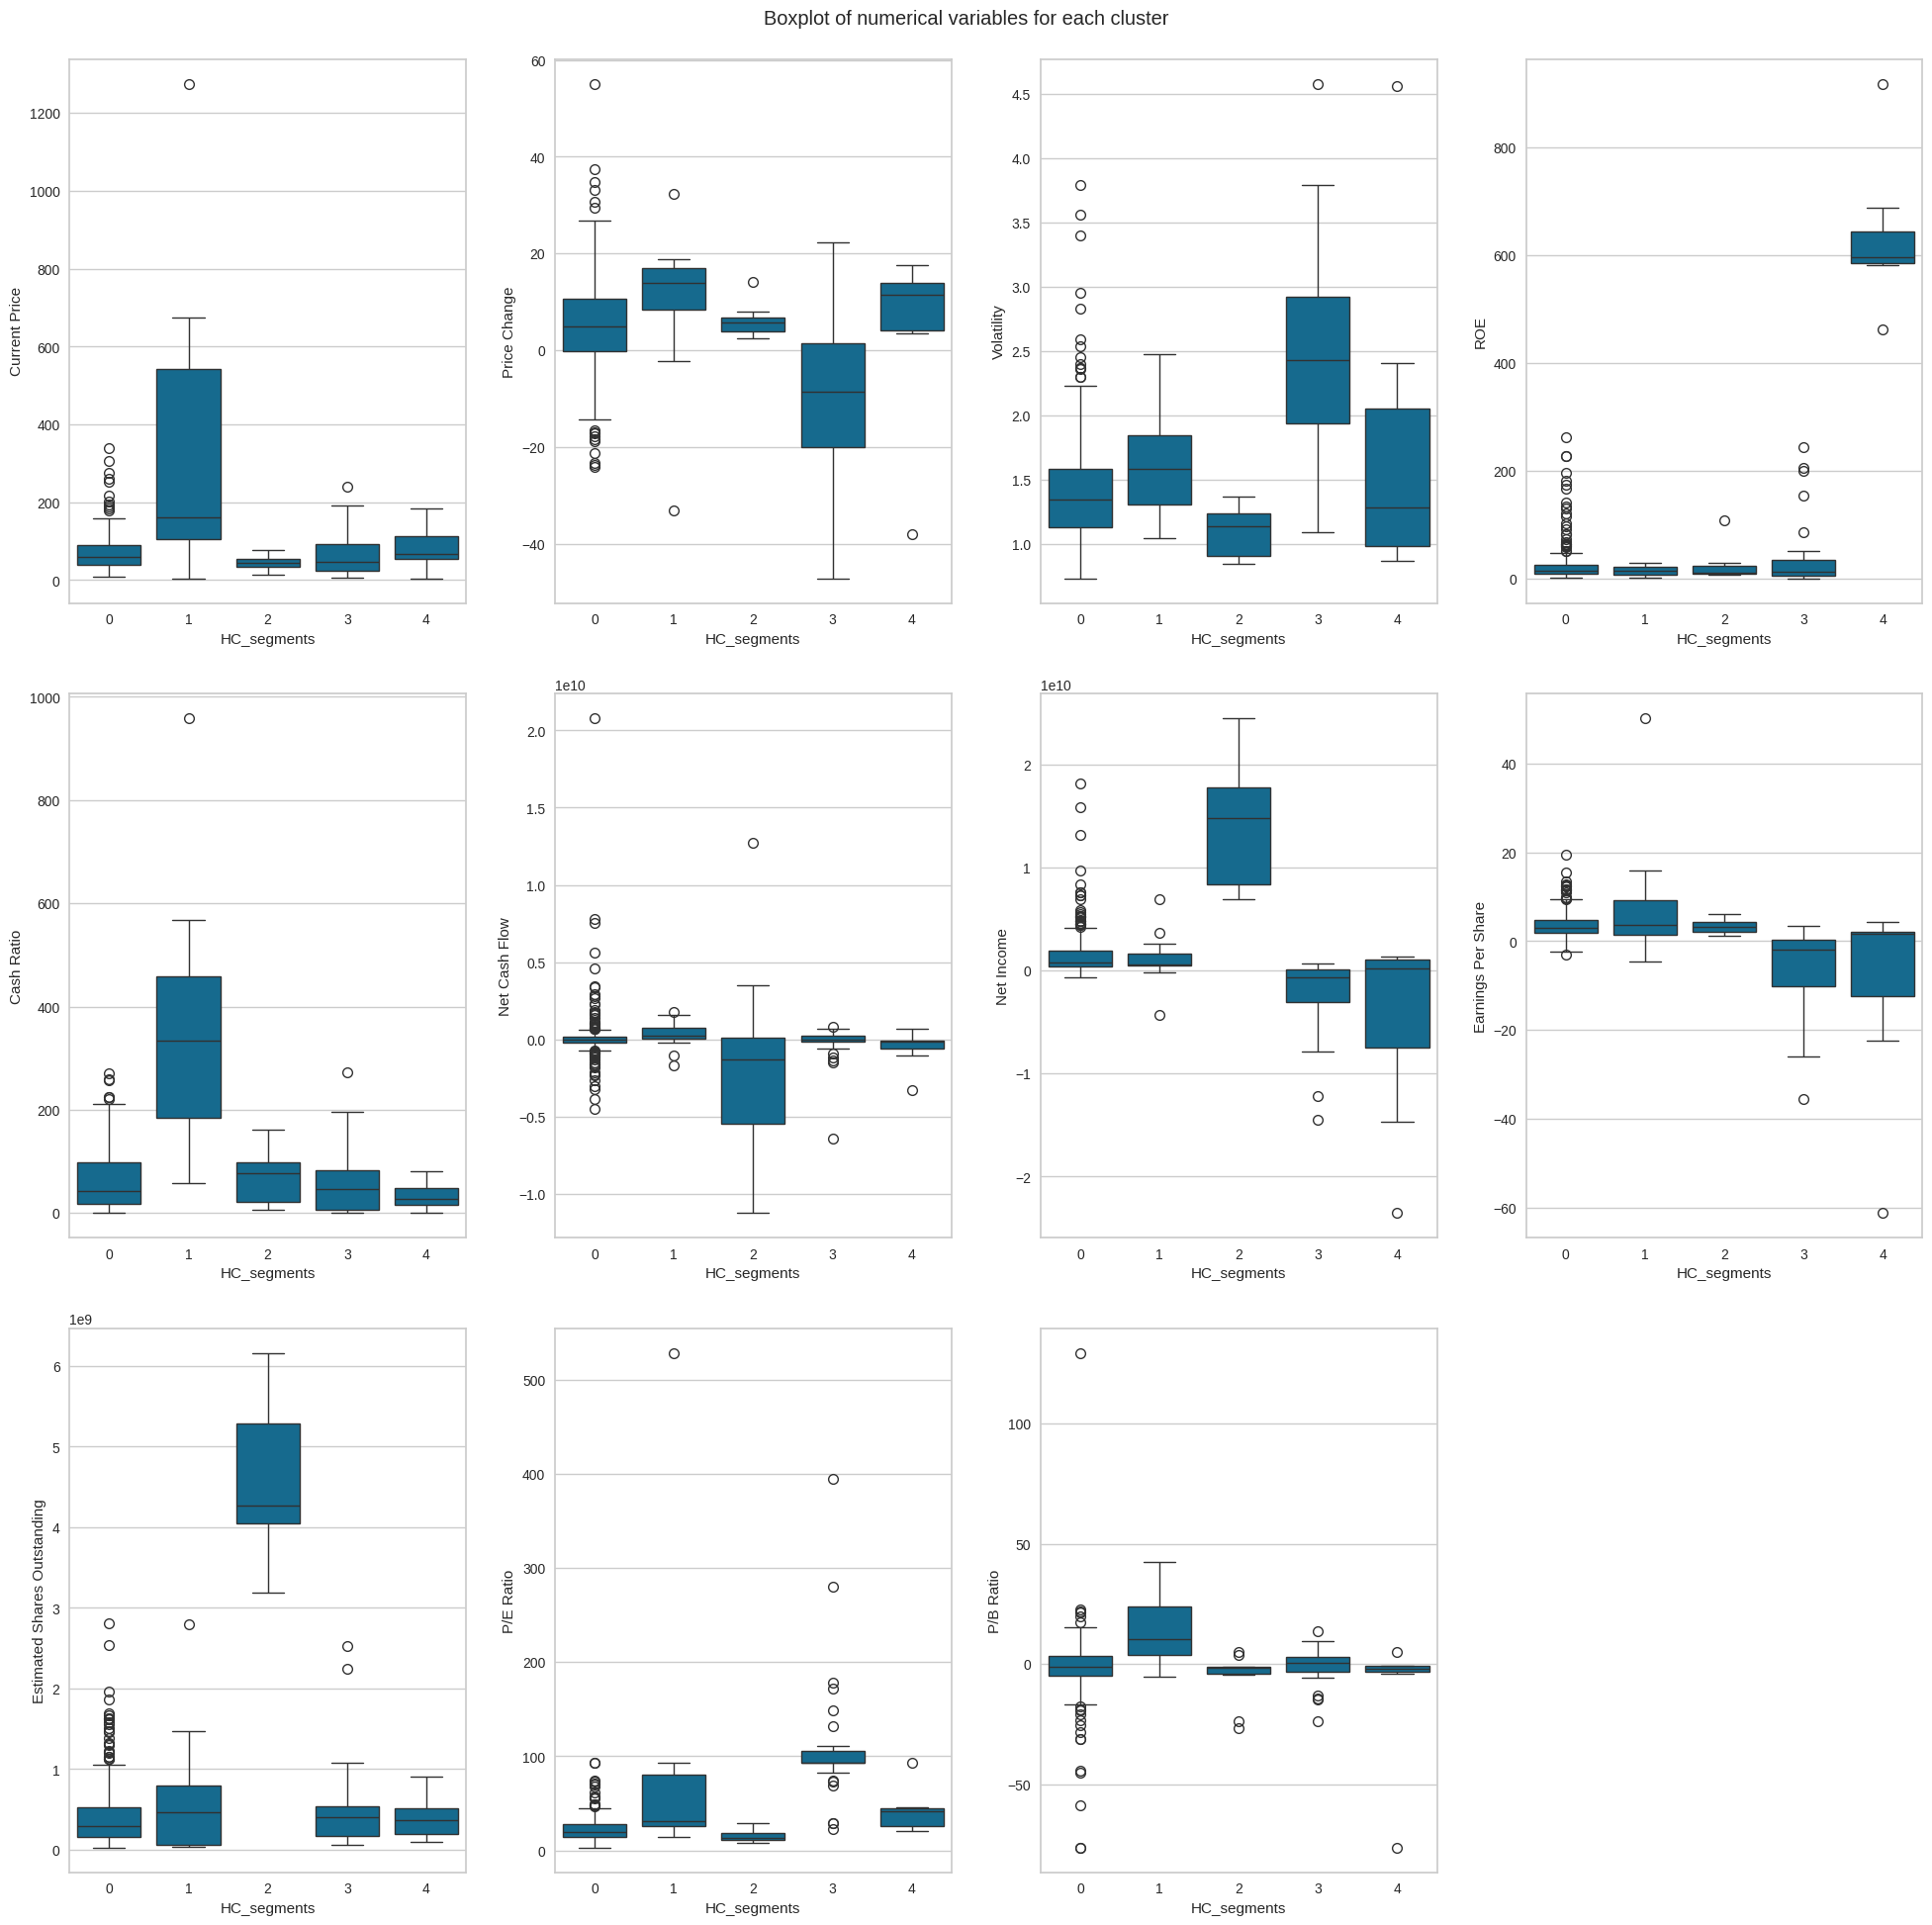

In [50]:
# Visualizing all 5 clusters in each column
plt.figure(figsize=(20, 20))
plt.suptitle("Boxplot of numerical variables for each cluster")

for i, variable in enumerate(num_col):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(data=df2, x="HC_segments", y=variable)

plt.tight_layout(pad=2.0)

## K-means vs Hierarchical Clustering

You compare several things, like:
- Which clustering technique took less time for execution?
- Which clustering technique gave you more distinct clusters, or are they the same?
- How many observations are there in the similar clusters of both algorithms?
- How many clusters are obtained as the appropriate number of clusters from both algorithms?

You can also mention any differences or similarities you obtained in the cluster profiles from both the clustering techniques.



*   **Cluster Distinctness and Interpretability:**
    *   K-Means: The silhouette plots showed some well-defined clusters, but also some observations near the zero line, indicating potential overlap. The cluster profiles derived from K-Means were generally distinct.
    *   Hierarchical Clustering : The dendrogram for Ward linkage clearly showed distinct groupings, and the subsequent boxplots for the 5 clusters also exhibited clear differentiation across various financial metrics. This suggests good interpretability, which was a key reason for its selection.

*  Execution Time:
    *   Generally, K-Means is computationally more efficient and faster for large datasets. Hierarchical clustering, especially with methods that build a full dendrogram, can be slower as it involves calculating distances between all pairs of data points or clusters. For this dataset size, both were performant.

*  Cluster Profiles - Similarities and Differences:
    *   Large 'Average' or 'Stable' Segment: Both models identified a dominant cluster representing companies with mid-range prices, moderate volatility, and stable, positive financial performance.
    *   'Distressed' or 'High-Risk' Segments: Both models successfully isolated groups of companies exhibiting negative profitability, high volatility, and often lower stock prices. Hierarchical clustering further segmented this into two distinct groups, providing a more granular view of risk.
    *   'High-Value' / 'Growth' Segments: K-Means identified a 'Highest Current Price, High Net Income, High Shares Outstanding' cluster. Hierarchical clustering also identified a segment of 'High-Value, High-Cash Growth Stocks' characterized by very high current price and cash ratio, and high P/E, suggesting different investment profiles within the 'high-value' category.
    *  Unique Hierarchical Cluster: HC Segment 2 was a distinct group of low current price and low volatility companies that didn't have a direct, strong counterpart in the K-Means 4-cluster solution.

## Actionable Insights and Recommendations





#### **HC Segment 0: The "Steady Performers"** (284 companies)
*   **Characteristics**: This is the largest segment, representing the majority of companies. They exhibit moderate current prices, positive price changes, and moderate volatility. Their financial health indicators (Net Cash Flow, Net Income, EPS) are generally positive, and their P/E and P/B ratios are balanced.
*   **Insights**: These companies are likely established, mature businesses with stable operations and consistent, albeit not explosive, growth. They form the backbone of a diversified portfolio.
*   **Recommendations**:
    *   **For Conservative Investors**: Ideal for investors seeking stable, long-term capital appreciation with moderate risk. Recommend these as core holdings.
    *   **For Growth-Oriented Investors**: Can provide ballast to a portfolio, offering reliable returns while higher-risk assets are pursued. Look for opportunities within this segment based on sector trends or specific company fundamentals.
    *   **Diversification**: Encourage diversification across GICS sectors within this segment to mitigate sector-specific risks.


#### **HC Segment 1: The "High-Value, High-Cash Growth Stocks"** (13 companies)
*   **Characteristics**: A small, elite group with very high current stock prices, strong positive price changes, and high cash ratios. They demonstrate high profitability (Net Income, EPS) and strong cash generation (Net Cash Flow). Notably, they also have very high P/E ratios.
*   **Insights**: These are likely leading growth companies that the market highly values, possibly due to innovation, market dominance, or strong future prospects. Their high cash reserves suggest financial strength and flexibility.
*   **Recommendations**:
    *   **For Growth and Aggressive Investors**: Suitable for investors with a higher risk tolerance seeking substantial capital gains. The high P/E ratio indicates premium valuation, so careful due diligence on growth sustainability is crucial.
    *   **Strategic Allocation**: Consider these for a portion of the portfolio focused on high-growth areas. Monitor market sentiment and growth projections closely.
    *   **Risk Management**: While financially strong, their high valuation makes them susceptible to market corrections if growth expectations are not met.


#### **HC Segment 2: The "Lower-Priced, Stable Niche Players"** (10 companies)
*   **Characteristics**: This small segment consists of companies with low current prices, positive price changes, and the lowest volatility among all clusters. They show moderate, positive financial performance across all profitability metrics and ratios.
*   **Insights**: These could be undervalued small-cap companies, or stable businesses operating in niche markets with consistent performance but less market attention. Their low volatility makes them relatively safe within their price bracket.
*   **Recommendations**:
    *   **For Value and Long-Term Investors**: Explore these companies for potential value plays or hidden gems. Their low volatility can make them attractive for risk-averse investors seeking growth in smaller market caps.
    *   **Fundamental Analysis**: Recommend in-depth research into their business models, competitive advantages, and market positioning to uncover growth catalysts.


#### **HC Segment 3: The "Volatile Underperformers"** (29 companies)
*   **Characteristics**: These companies exhibit high volatility and a negative price change, indicating recent struggles. Their cash ratios are lower, and profitability metrics (Net Cash Flow, Net Income, EPS) are also lower, with some even being negative. P/E and P/B ratios are highly variable and can be high (potentially due to low earnings).
*   **Insights**: This segment comprises companies facing significant operational or market challenges, leading to underperformance and increased risk. They might be in a turnaround phase or experiencing sustained difficulties.
*   **Recommendations**:
    *   **For Speculative Investors (with extreme caution)**: Only suitable for investors with a high-risk appetite looking for deep value or turnaround opportunities. Emphasize extensive research into the company's financials, management strategy, and industry outlook.
    *   **Avoid for Conservative Investors**: Strongly advise conservative investors to avoid this segment due to high risk and volatility.
    *   **Diversification**: If investing, suggest very small allocations to individual stocks in this segment to manage overall portfolio risk.


#### **HC Segment 4: The "Distressed/High-Risk Stocks"** (4 companies)
*   **Characteristics**: The smallest and most concerning segment. Companies here have low current prices, significantly negative price changes, and high volatility. All profitability metrics (Net Cash Flow, Net Income, EPS) are substantially negative. Their P/E and P/B ratios are highly erratic, often reflecting negative equity or earnings.
*   **Insights**: These companies are in severe financial distress, potentially facing bankruptcy, restructuring, or sustained operational losses. They represent the highest level of investment risk.
*   **Recommendations**:
    *   **Extreme Caution/Avoidance**: Advise most investors, especially retail investors, to avoid this segment entirely. The potential for loss is very high.
    *   **For Highly Specialized Investors**: Only suitable for highly experienced and speculative investors who specialize in distressed assets or short-selling, and are prepared for potential complete loss of capital. These investments require advanced market knowledge and risk management strategies.
